# Week 7 - Model Optimisation and Engineering Trade-offs

# SECTION 1: Baseline Model of an Explainable AI Assistant to Support Emergency Department Triage (Week 6)

**Author**: Sariana Ramoutar

This notebook develops baseline machine learning models to predict Emergency Severity Index (ESI) levels using emergency department triage data.

The workflow follows good machine learning practice by:
- loading and preparing the data
- preventing data leakage
- splitting the data into training and testing sets
- training baseline classifiers
- evaluating model performance
- comparing against a random baseline
- exploring model interpretability using Explainable AI principles.

## 1. Setting Up the Workspace

In [1]:
# Import necessary libraries for data handling, plotting, and file operations.
import os # For interacting with the operating system, e.g., creating directories.
import pandas as pd # For data manipulation and analysis using DataFrames.
import numpy as np # For numerical operations.
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualisations.
import seaborn as sns # For making attractive and informative statistical graphics.

In [2]:
# Set pandas display options to ensure that DataFrames are fully visible and easy to read.
# 'display.max_columns = None' ensures all columns are shown.
# 'display.max_rows = 100' ensures up to 100 rows are shown before truncation.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
# Define the folder names for storing figures (plots) and trained models.
FIGS_FOLDER = 'figs'
MODELS_FOLDER = 'models'

# Create the 'figs' folder if it does not already exist.
# This ensures a place to save any visualisations generated.
if not os.path.exists(FIGS_FOLDER):
    os.makedirs(FIGS_FOLDER)
    print(f"Created folder: {FIGS_FOLDER}/")

# Create the 'models' folder if it does not already exist.
# This ensures a place to save any machine learning models trained later.
if not os.path.exists(MODELS_FOLDER):
    os.makedirs(MODELS_FOLDER)
    print(f"Created folder: {MODELS_FOLDER}/")

Created folder: figs/
Created folder: models/


## 2. Loading the Patient Data

In [4]:
# Mount Google Drive to allow this Colab notebook to access files stored in your Drive.
# A pop-up will appear asking for authentication to connect to your Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Define the file path for the cleaned CSV dataset in Google Drive.
FILE_PATH = '/content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv'

# Load the cleaned CSV file into a pandas DataFrame.
# This dataset is expected to be pre-processed and ready for modelling.
triage_df = pd.read_csv(FILE_PATH)

# Print a confirmation message to indicate successful data loading.
print(f"Successfully loaded data from: {FILE_PATH}")

Successfully loaded data from: /content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv


In [6]:
# Print the number of rows (observations) and columns (features) in the loaded DataFrame.
# This gives a quick overview of the dataset's size.
print(f"The dataset contains {triage_df.shape[0]} rows and {triage_df.shape[1]} columns.")

# Display the first 5 rows of the DataFrame.
# This helps in quickly inspecting the data structure, column names, and initial values.
print("\nFirst 5 rows of the dataset:")
display(triage_df.head())

The dataset contains 55121 rows and 226 columns.

First 5 rows of the dataset:


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,cc_breastpain,cc_breathingdifficulty,cc_breathingproblem,cc_burn,cc_cardiacarrest,cc_cellulitis,cc_chestpain,cc_chesttightness,cc_chills,cc_coldlikesymptoms,cc_confusion,cc_conjunctivitis,cc_constipation,cc_cough,cc_cyst,cc_decreasedbloodsugar-symptomatic,cc_dehydration,cc_dentalpain,cc_depression,cc_detoxevaluation,cc_diarrhea,cc_dizziness,cc_drug/alcoholassessment,cc_drugproblem,cc_dyspnea,cc_dysuria,cc_earpain,cc_earproblem,cc_edema,cc_elbowpain,cc_elevatedbloodsugar-nosymptoms,cc_elevatedbloodsugar-symptomatic,cc_emesis,cc_epigastricpain,cc_epistaxis,cc_exposuretostd,cc_extremitylaceration,cc_extremityweakness,cc_eyeinjury,cc_eyepain,cc_eyeproblem,cc_eyeredness,cc_facialinjury,cc_faciallaceration,cc_facialpain,cc_facialswelling,cc_fall,cc_fall>65,cc_fatigue,cc_femaleguproblem,cc_fever,cc_fever-75yearsorolder,cc_fever-9weeksto74years,cc_feverimmunocompromised,cc_fingerinjury,cc_fingerpain,cc_fingerswelling,cc_flankpain,cc_follow-upcellulitis,cc_footinjury,cc_footpain,cc_footswelling,cc_foreignbodyineye,cc_fulltrauma,cc_generalizedbodyaches,cc_gibleeding,cc_giproblem,cc_groinpain,cc_hallucinations,cc_handinjury,cc_handpain,cc_headache,cc_headache-newonsetornewsymptoms,cc_headache-recurrentorknowndxmigraines,cc_headachere-evaluation,cc_headinjury,cc_headlaceration,cc_hematuria,cc_hemoptysis,cc_hippain,cc_homicidal,cc_hyperglycemia,cc_hypertension,cc_hypotension,cc_influenza,cc_ingestion,cc_insectbite,cc_irregularheartbeat,cc_jawpain,cc_jointswelling,cc_kneeinjury,cc_kneepain,cc_laceration,cc_leginjury,cc_legpain,cc_legswelling,cc_lethargy,cc_lossofconsciousness,cc_maleguproblem,cc_mass,cc_medicalproblem,cc_medicalscreening,cc_medicationproblem,cc_medicationrefill,cc_migraine,cc_modifiedtrauma,cc_motorcyclecrash,cc_motorvehiclecrash,cc_multiplefalls,cc_nasalcongestion,cc_nausea,cc_nearsyncope,cc_neckpain,cc_neurologicproblem,cc_numbness,cc_oralswelling,cc_otalgia,cc_other,cc_overdose-accidental,cc_overdose-intentional,cc_pain,cc_palpitations,cc_panicattack,cc_pelvicpain,cc_poisoning,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [7]:
# Check for any missing values across all columns in the DataFrame.
# '.isnull()' identifies missing values, and '.sum()' counts them per column.
missing_values_summary = triage_df.isnull().sum()

# Filter the summary to only show columns that have at least one missing value.
# This provides a concise report of any data completeness issues.
missing_values_summary = missing_values_summary[missing_values_summary > 0]

# Display the summary of missing values.
if not missing_values_summary.empty:
    print("\nSummary of missing values per column:")
    display(missing_values_summary)
else:
    print("\nNo missing values found in the dataset, as expected from a 'cleaned' dataset.")


No missing values found in the dataset, as expected from a 'cleaned' dataset.


/tmp/ipykernel_3572/1991818670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='esi', data=triage_df, order=sorted(triage_df['esi'].unique()), palette='cool')


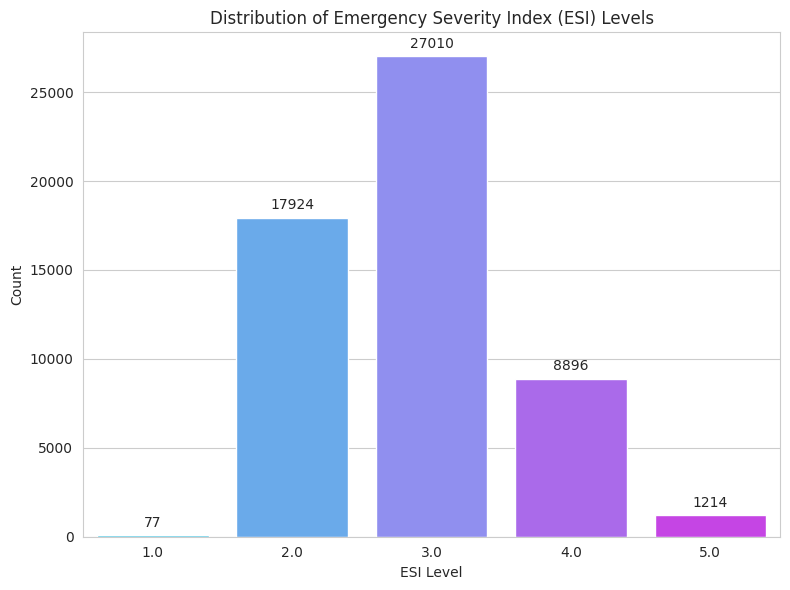

In [8]:
# Visualise the distribution of the target variable, 'esi' (Emergency Severity Index).
# This plot helps to understand the frequency of each ESI level in the dataset.

# Set the aesthetic style of the plots for better readability.
sns.set_style("whitegrid")

# Create a figure and an axes object for the plot with a specified size.
plt.figure(figsize=(8, 6))

# Use seaborn's countplot to show the distribution of 'esi' levels.
# 'order' ensures the ESI levels are plotted in numerical order on the x-axis.
sns.countplot(x='esi', data=triage_df, order=sorted(triage_df['esi'].unique()), palette='cool')

# Add a descriptive title to the plot.
plt.title('Distribution of Emergency Severity Index (ESI) Levels')

# Label the x-axis and y-axis clearly.
plt.xlabel('ESI Level')
plt.ylabel('Count')

# Display the exact count of each ESI level on top of the bars for quick reference.
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points')

# Adjust layout to prevent labels from being cut off and then display the plot.
plt.tight_layout()
plt.show()

### Understanding the Target Variable Distribution

As observed from the plot above, the Emergency Severity Index (ESI) is an imbalanced multi-class target variable. This means that some ESI levels appear much more frequently than others. In a clinical context, accurately predicting the rarer ESI levels (e.g., ESI 1 or ESI 5) is often critically important, despite their lower frequency in the dataset. This imbalance will need to be carefully considered during model training and evaluation to ensure robust performance across all ESI levels.

In [9]:
# Inspect all column names in the dataset to verify exact vital sign naming.
# Since our feature selection returned 0 vital sign columns, this list will
# allow us to find the exact strings used for temperature, heart rate, etc.
print("======= Column Name Inspection =======")
print(f"Listing all {triage_df.shape[1]} columns in alphabetical order:\n")

# Loop through and print each column name in a clean, scrollable list
for col in sorted(triage_df.columns):
    print(col)

print("======================================")

======= Column Name Inspection =======
Listing all 226 columns in alphabetical order:

Unnamed: 0
age
arrivalday
arrivalhour_bin
arrivalmode
arrivalmonth
cc_abdominalcramping
cc_abdominaldistention
cc_abdominalpain
cc_abdominalpainpregnant
cc_abnormallab
cc_abscess
cc_addictionproblem
cc_agitation
cc_alcoholintoxication
cc_alcoholproblem
cc_allergicreaction
cc_alteredmentalstatus
cc_animalbite
cc_ankleinjury
cc_anklepain
cc_anxiety
cc_arminjury
cc_armpain
cc_armswelling
cc_assaultvictim
cc_asthma
cc_backpain
cc_bleeding/bruising
cc_blurredvision
cc_bodyfluidexposure
cc_breastpain
cc_breathingdifficulty
cc_breathingproblem
cc_burn
cc_cardiacarrest
cc_cellulitis
cc_chestpain
cc_chesttightness
cc_chills
cc_coldlikesymptoms
cc_confusion
cc_conjunctivitis
cc_constipation
cc_cough
cc_cyst
cc_decreasedbloodsugar-symptomatic
cc_dehydration
cc_dentalpain
cc_depression
cc_detoxevaluation
cc_diarrhea
cc_dizziness
cc_drug/alcoholassessment
cc_drugproblem
cc_dyspnea
cc_dysuria
cc_earpain
cc_earprob

## 3. Selecting Features for Clinical Prediction

### Understanding the Target Variable

In this predictive modelling task, the **target variable** is the Emergency Severity Index (`esi`). The ESI is a five-level emergency department triage algorithm that categorises patients by severity and resource needs, ranging from ESI 1 (most urgent) to ESI 5 (least urgent). The goal is to train a machine learning model that can accurately predict a patient's ESI level based on information available at triage. This prediction can help clinicians to quickly assess patient acuity and allocate resources effectively.

In [10]:
# Define the target variable's column name.
TARGET = 'esi'

# Define lists of column names that fall into different categories.
# These lists are based on common conventions in healthcare datasets like CariSurg tutorials.

# Demographics: Patient-specific information that might not be used as features in some models
# due to fairness considerations or clinical relevance for prediction.
DEMOGRAPHICS = [
    'age',
    'gender',
    'ethnicity',
    'race',
    'insurance_type'
]

# Administrative variables: Identifiers or system-generated codes not directly related to clinical state.
# 'Unnamed: 0' is often an artefact from CSV saving and should generally be excluded.
ADMIN = [
    'Unnamed: 0',
    'dep_name',
    'patient_id',
    'encounter_id',
    'visit_id',
    'disposition_id'
]

# Leakage variables: Information that would not be available at the time of triage prediction,
# or that directly or indirectly reveals the target variable. Using these would make the model
# seem artificially accurate.
LEAKAGE = [
    'n_edvisits', # Number of past ED visits, could be proxy for severity over time
    'n_admissions', # Number of past admissions, similar to n_edvisits
    'admitted_to_hospital', # Outcome post-triage, direct leakage
    'admission_type', # Type of admission, often determined post-triage
    'admission_source', # Source of admission, often determined post-triage
    'discharge_disposition', # Outcome after admission, direct leakage
    'discharge_destination', # Destination after discharge, direct leakage
    'length_of_stay', # Duration of hospital stay, direct leakage
    'admission_to_icu_flag', # Indicates ICU admission, direct leakage
    'icu_stay_days', # Duration of ICU stay, direct leakage
    'mortality_flag', # Indicates mortality, direct leakage
    'disposition_dt', # Date of disposition, indicates post-triage event
    'discharge_dt' # Date of discharge, indicates post-triage event
]

# Triage vital signs: Core physiological measurements taken during triage.
# These are crucial clinical features.
VITAL_SIGNS = [
    'triage_vital_dbp',
    'triage_vital_hr',
    'triage_vital_o2',
    'triage_vital_rr',
    'triage_vital_sbp',
    'triage_vital_temp',
    'triage_glucose'
]

# Combine all exclusion lists into one for easier filtering.
EXCLUDE_COLS = list(set(DEMOGRAPHICS + ADMIN + LEAKAGE + [TARGET]))

# Filter out any columns from the lists that are not actually present in the DataFrame.
# This prevents errors if the dataset does not contain all theoretical columns.
DEMOGRAPHICS = [col for col in DEMOGRAPHICS if col in triage_df.columns]
ADMIN = [col for col in ADMIN if col in triage_df.columns]
LEAKAGE = [col for col in LEAKAGE if col in triage_df.columns]
VITAL_SIGNS = [col for col in VITAL_SIGNS if col in triage_df.columns]
EXCLUDE_COLS = [col for col in EXCLUDE_COLS if col in triage_df.columns]

print(f"Target variable defined: {TARGET}")
print(f"Number of identified demographic columns: {len(DEMOGRAPHICS)}")
print(f"Number of identified administrative columns: {len(ADMIN)}")
print(f"Number of identified leakage columns: {len(LEAKAGE)}")
print(f"Number of identified vital sign columns: {len(VITAL_SIGNS)}")

Target variable defined: esi
Number of identified demographic columns: 4
Number of identified administrative columns: 2
Number of identified leakage columns: 0
Number of identified vital sign columns: 7


### The Importance of Avoiding Data Leakage

**Data leakage** occurs when information that would not be available at the time of prediction is used to train a machine learning model. In a clinical context, this typically means using data that becomes known *after* the initial triage assessment but before or during the patient's full clinical course (e.g., whether a patient was admitted to the hospital, their length of stay, or final diagnosis). If a model is trained with such 'leaked' information, it will appear to perform extremely well during testing because it's essentially peeking at the answer. However, when deployed in a real-world scenario (e.g., at the point of triage), this information would not yet exist, and the model's performance would drastically drop.

To ensure the model is truly predictive and clinically useful, it is crucial to identify and exclude all leakage variables. The goal is to build a model that can make an accurate `esi` prediction using **only** the information available at the very start of a patient's emergency department visit.

In [11]:
# Create a working copy of the DataFrame to perform feature selection.
df_prepared = triage_df.copy()

# --- 1. Remove rows where the target variable is missing ---
# Although the initial check showed no missing values, this is a good practice step.
# It ensures that our model training will not be affected by undefined target outcomes.
original_rows = df_prepared.shape[0]
df_prepared.dropna(subset=[TARGET], inplace=True)
rows_after_target_nan_removal = df_prepared.shape[0]

if original_rows - rows_after_target_nan_removal > 0:
    print(f"Removed {original_rows - rows_after_target_nan_removal} rows due to missing target variable '{TARGET}'.")
else:
    print(f"No rows removed as target variable '{TARGET}' had no missing values.")


# --- 2. Select clinically available features ---

# Identify all chief complaint (cc_) columns that are numerical.
# These columns typically represent the presence or absence of a chief complaint.
cc_cols = [col for col in df_prepared.columns if col.startswith('cc_') and pd.api.types.is_numeric_dtype(df_prepared[col])]

# Combine vital signs and chief complaints to form the initial set of selected features.
selected_features = list(set(VITAL_SIGNS + cc_cols))

# Filter out any features that are in our exclusion list.
# This ensures no demographic, administrative, or leakage variables are included.
final_features = [col for col in selected_features if col not in EXCLUDE_COLS]

# Ensure the target variable is not accidentally in the final features list.
if TARGET in final_features:
    final_features.remove(TARGET)

# --- 3. Create feature matrix (X) and target vector (y) ---

# X will contain all the selected features that the model will use for prediction.
X = df_prepared[final_features]

# y will contain the target variable, which is what the model will try to predict.
y = df_prepared[TARGET]

print(f"\nTotal columns in original DataFrame: {triage_df.shape[1]}")
print(f"Number of initial chief complaint (cc_) variables detected: {len(cc_cols)}")
print(f"Number of core vital sign variables included: {len(VITAL_SIGNS)}")
print(f"Number of final selected features for X: {X.shape[1]}")
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

No rows removed as target variable 'esi' had no missing values.

Total columns in original DataFrame: 226
Number of initial chief complaint (cc_) variables detected: 200
Number of core vital sign variables included: 7
Number of final selected features for X: 207
Shape of X (features): (55121, 207)
Shape of y (target): (55121,)


In [12]:
# --- Fill missing feature values with the median ---
# For robust models, it's good practice to handle missing values in features.
# Using the median is a common strategy for numerical data as it is less sensitive
# to outliers than the mean.

# Calculate the median for each feature column in X.
# We store these medians so they can be used consistently for any future unseen data.
feature_medians = X.median()

# Although this dataset contained no missing feature values, the median-imputation code was retained as good
# machine learning practice and ensures the workflow remains robust if future datasets contain missing observations.

# Fill any missing (NaN) values in X using the calculated median for each respective column.
X_filled = X.fillna(feature_medians)

# Verify that there are no remaining missing values in the feature set.
missing_values_after_fill = X_filled.isnull().sum().sum()

print(f"Missing values in features before filling: {X.isnull().sum().sum()}")
print(f"Missing values in features after filling with median: {missing_values_after_fill}")

Missing values in features before filling: 0
Missing values in features after filling with median: 0


In [13]:
# --- Print a neat summary of the prepared dataset ---
patients_count = X_filled.shape[0]
features_count = X_filled.shape[1]
remaining_missing = X_filled.isnull().sum().sum()

print("\n==================================================")
print("             Dataset Preparation Summary")
print("==================================================")
print(f"Number of patients (rows) in X: {patients_count}")
print(f"Number of selected features (columns) in X: {features_count}")
print(f"Target variable: {TARGET}")
print(f"Remaining missing values in X: {remaining_missing}") # Should be 0
print("==================================================")


             Dataset Preparation Summary
Number of patients (rows) in X: 55121
Number of selected features (columns) in X: 207
Target variable: esi
Remaining missing values in X: 0


In [14]:
# --- Produce a small table listing the core triage vital signs included ---
# This table clearly presents the vital sign features that will be used by the model.

print("\nCore Triage Vital Signs Included:")
vital_signs_df = pd.DataFrame(VITAL_SIGNS, columns=['Vital Sign Feature'])
display(vital_signs_df)


Core Triage Vital Signs Included:


,Vital Sign Feature
0,triage_vital_dbp
1,triage_vital_hr
2,triage_vital_o2
3,triage_vital_rr
4,triage_vital_sbp
5,triage_vital_temp
6,triage_glucose


In [15]:
# --- Produce a second table showing the number of chief complaint variables ---
# This table summarises how many chief complaint indicators are part of the feature set.

# Re-detect cc_cols from X_filled columns to be accurate after feature selection
final_cc_cols = [col for col in X_filled.columns if col.startswith('cc_')]

print("\nSummary of Chief Complaint Variables:")
cc_summary_df = pd.DataFrame({'Category': ['Number of Chief Complaint Variables'], 'Count': [len(final_cc_cols)]})
display(cc_summary_df)


Summary of Chief Complaint Variables:


,Category,Count
0,Number of Chief Complaint Variables,200


/tmp/ipykernel_3572/1541456572.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Feature Group', data=feature_groups_df, palette='cool')


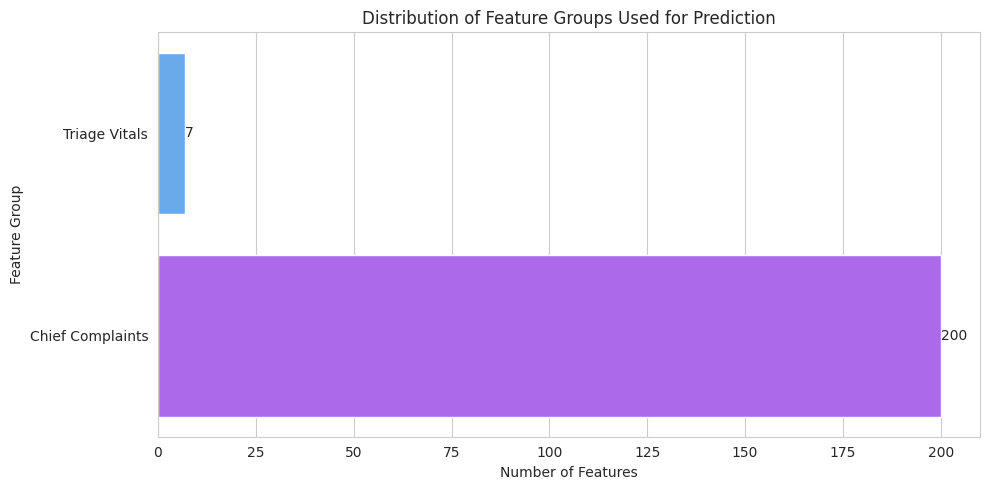

In [16]:
# --- Create a simple horizontal bar chart showing feature group counts ---
# This visualisation helps to quickly understand the composition of the feature set.

# Categorise features for plotting
included_vital_signs = [col for col in X_filled.columns if col in VITAL_SIGNS]
included_chief_complaints = [col for col in X_filled.columns if col.startswith('cc_')]

feature_groups_data = {
    'Feature Group': ['Triage Vitals', 'Chief Complaints'],
    'Count': [len(included_vital_signs), len(included_chief_complaints)]
}
feature_groups_df = pd.DataFrame(feature_groups_data)

plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Feature Group', data=feature_groups_df, palette='cool')
plt.title('Distribution of Feature Groups Used for Prediction')
plt.xlabel('Number of Features')
plt.ylabel('Feature Group')

# Add counts on the bars
for index, value in enumerate(feature_groups_df['Count']):
    plt.text(value, index, str(value), va='center') # va='center' for better vertical alignment

plt.tight_layout()
plt.show()

In [17]:
print("DATA PREPARATION SUMMARY")
print(f"Patients included: {X_filled.shape[0]}")
print(f"Features selected: {X_filled.shape[1]}")
print("Missing values: 0")

DATA PREPARATION SUMMARY
Patients included: 55121
Features selected: 207
Missing values: 0


```
==================================================
✓ DATA PREPARATION COMPLETE

Patients included: 55121
Features selected: 207
Missing values: 0
Ready for train/test split.
==================================================
```

## 4. Preparing the Data for Machine Learning

### Part A – Why split the data

Before training any models, the data has to be separated into two distinct groups: a **Training Set** and a **Testing Set**.

*   **Training vs. Testing**: The training set is used by the model to learn relationships between features and the target. The testing set must remain 'unseen' during this process. This allows us to evaluate how well the model generalises to new, real-world patients rather than just memorising the data it has already seen.
*   **Stratification**: Since ESI levels are imbalanced (some levels appear much less frequently), we use stratification. This ensures that both the training and testing sets have the same percentage of each ESI level as the original dataset.
*   **Reproducibility**: Use a fixed 'random seed' (random_state=42). This ensures that every time the code is run, the split is identical, which is vital for scientific reproducibility.

### Part B – Train/test split

In [18]:
# Import the required utility from scikit-learn
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
# We use 'stratify=y' to ensure the ESI class balance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_filled,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Print the resulting patient counts for verification
print(f"Number of training patients: {X_train.shape[0]}")
print(f"Number of testing patients:  {X_test.shape[0]}")

Number of training patients: 44096
Number of testing patients:  11025


### Part C – Visualise the split

/tmp/ipykernel_3572/2185488707.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0], palette='cool')
/tmp/ipykernel_3572/2185488707.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[1], palette='cool')
/tmp/ipykernel_3572/2185488707.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, ax=axes[2], palette='cool')


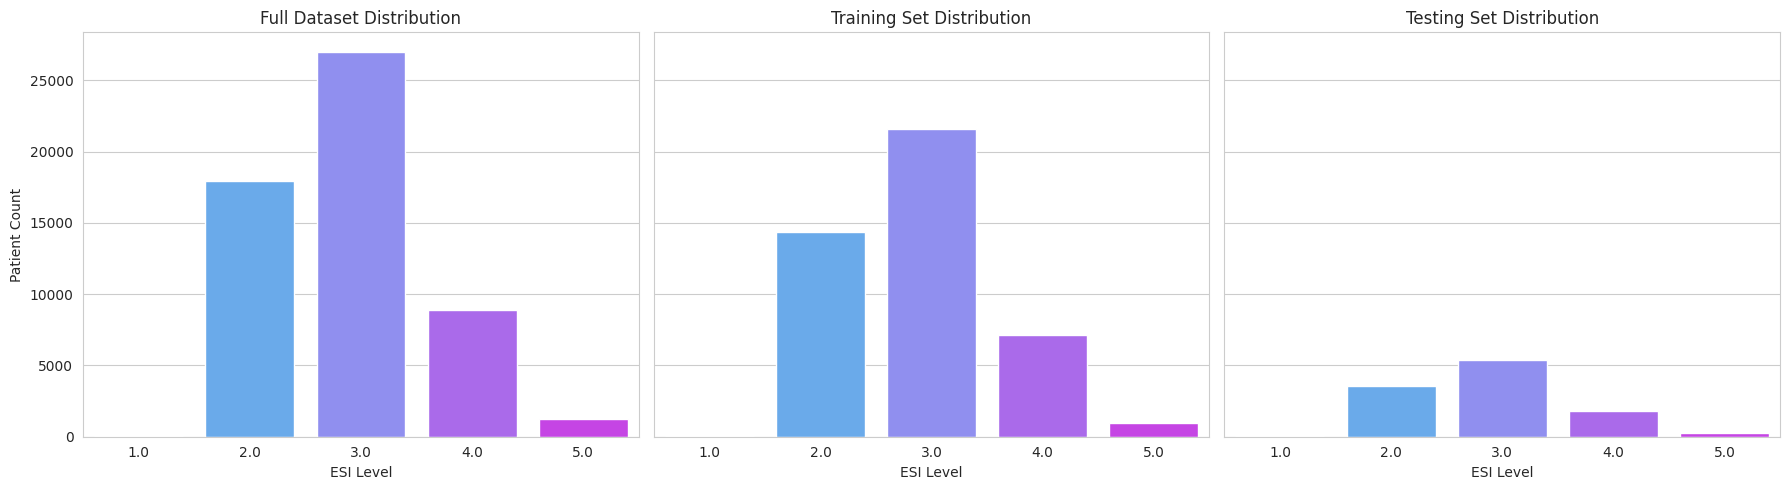

In [19]:
# Create a side-by-side comparison of the ESI distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot original full dataset
sns.countplot(x=y, ax=axes[0], palette='cool')
axes[0].set_title('Full Dataset Distribution')
axes[0].set_xlabel('ESI Level')
axes[0].set_ylabel('Patient Count')

# Plot training set
sns.countplot(x=y_train, ax=axes[1], palette='cool')
axes[1].set_title('Training Set Distribution')
axes[1].set_xlabel('ESI Level')

# Plot testing set
sns.countplot(x=y_test, ax=axes[2], palette='cool')
axes[2].set_title('Testing Set Distribution')
axes[2].set_xlabel('ESI Level')

plt.tight_layout()
plt.show()

As shown in the charts above, the stratification process has successfully preserved the class balance across both the training and testing sets, ensuring a fair evaluation environment.

### Part D – Feature scaling

Different models have different requirements regarding the scale of the input features:

*   **Logistic Regression**: This model uses weights to calculate importance. If features are on different scales (e.g., heart rate vs. a binary complaint), the model may struggle to converge or may incorrectly weight larger numbers. Scaling ensures all features have a mean of 0 and a standard deviation of 1.
*   **Decision Trees**: These models use simple value-based thresholds to split data. Because they only care about whether a value is 'greater than' or 'less than' a threshold, they are not affected by the scale of the data and do not require scaling.

In [20]:
# Import the standard scaling tool
from sklearn.preprocessing import StandardScaler

# Initialise the scaler
scaler = StandardScaler()

# We 'fit' the scaler ONLY on the training data to calculate means and standard deviations.
# This prevents information from the test set 'leaking' into our training process.
scaler.fit(X_train)

# Transform both training and testing sets using the parameters derived from the training set
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


### Part E – Final summary

In [21]:
# Final status report for Section 3
print("==================================================")
print("\u2713 DATA READY FOR MODELLING")
print(f"Training patients: {X_train.shape[0]}")
print(f"Testing patients:  {X_test.shape[0]}")
print(f"Features:          {X_train.shape[1]}")
print("Scaling completed for Logistic Regression.")
print("Decision Tree will use original values.")
print("==================================================")

✓ DATA READY FOR MODELLING
Training patients: 44096
Testing patients:  11025
Features:          207
Scaling completed for Logistic Regression.
Decision Tree will use original values.


## 5. Building Baseline Machine Learning Models

In this section, three different baseline models will be trained. These models provide a starting point for the prediction task before moving on to more complex evaluations in the next stage.

### Part A – Dummy Classifier

**Why use a Dummy Classifier?**

A `DummyClassifier` is a simple model that makes predictions using basic rules, such as always predicting the most frequent class or guessing based on the class distribution. It does not actually 'learn' from the clinical features. It is used as a baseline reference; if the machine learning models cannot outperform this simple 'guesser', it indicates that they are not finding useful patterns in the data.

In [22]:
from sklearn.dummy import DummyClassifier

# Initialise the Dummy Classifier using the 'stratified' strategy.
# This strategy makes random guesses that match the distribution of the training set.
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)

# Train the model using the unscaled training data.
dummy_clf.fit(X_train, y_train)

# Print a success checkpoint.
print("\u2713 Dummy Classifier trained successfully")
print(f"Strategy used:    {dummy_clf.strategy}")
print(f"Training samples: {len(X_train)}")
print(f"Features:         {X_train.shape[1]}")

✓ Dummy Classifier trained successfully
Strategy used:    stratified
Training samples: 44096
Features:         207


### Part B – Logistic Regression

**What is Logistic Regression?**

Logistic Regression is a fundamental baseline classifier used for classification. Despite its name, it is used to predict categories (like ESI levels).

*   **Clinical Strength**: It is widely used in medicine because it provides a 'weight' (coefficient) for every feature, showing exactly how much each vital sign or complaint contributes to the risk.
*   **Scaling**: As discussed previously, the **scaled** features (`X_train_scaled`) are used here to ensure the model treats all clinical measurements fairly, regardless of their original numerical range.

In [23]:
from sklearn.linear_model import LogisticRegression

# Initialise Logistic Regression.
# 'multi_class="auto"' and 'max_iter=1000' ensure it handles our 5 ESI levels correctly.
log_reg = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=1000, random_state=42)

# Train the model using the SCALED training data.
log_reg.fit(X_train_scaled, y_train)

# Print a success checkpoint.
print("\u2713 Logistic Regression trained successfully")
print(f"Training samples: {len(X_train)}")
print(f"Features:         {X_train.shape[1]}")
print("Scaled data used: Yes")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✓ Logistic Regression trained successfully
Training samples: 44096
Features:         207
Scaled data used: Yes


### Part C – Logistic Regression Visualisation

By looking at the coefficients, we can see which clinical features the model finds most important. Larger positive or negative coefficients indicate variables that have a greater influence on the model's decision to predict a specific ESI level.

/tmp/ipykernel_3572/1225429309.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_20_coefs, palette='cool')


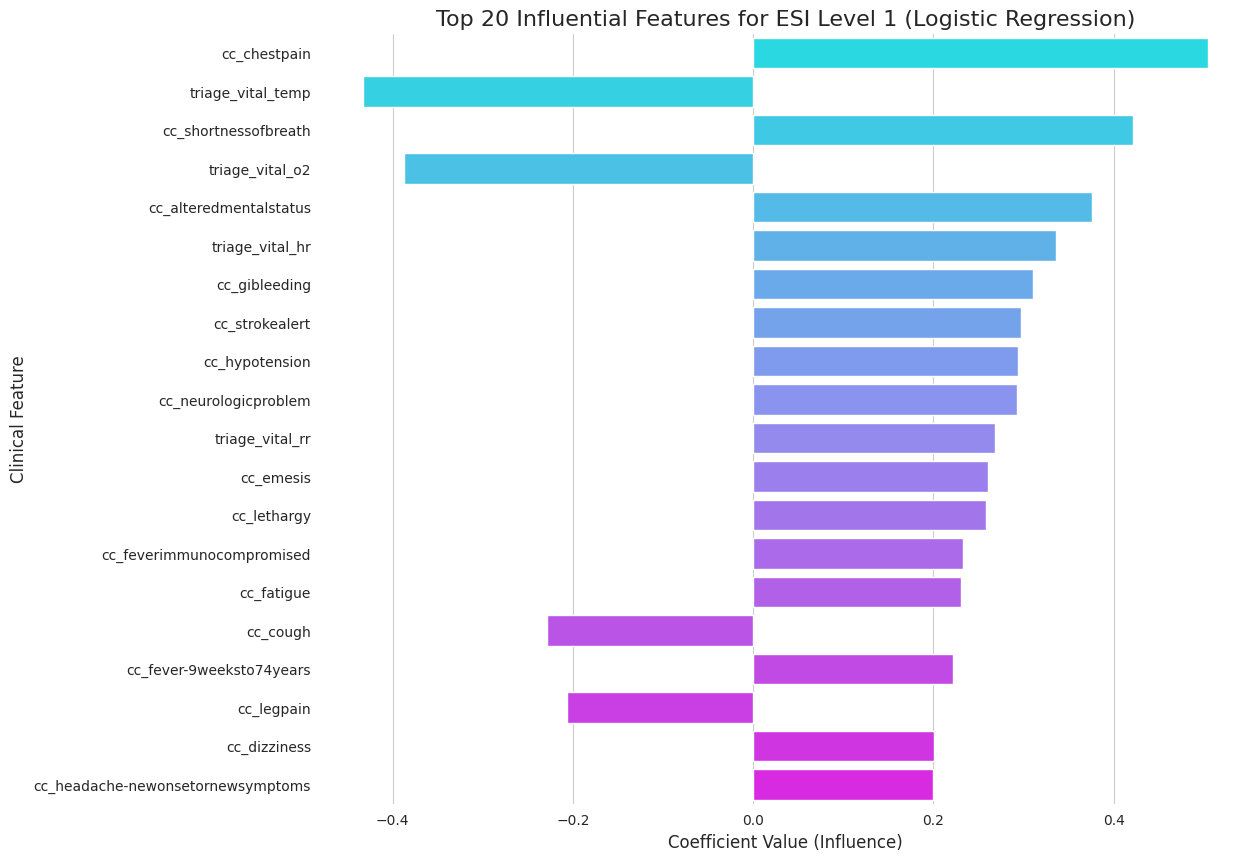

In [24]:
# Extract coefficients for ESI Level 1 (Index 0)
esi_1_coefs = log_reg.coef_[0]

# Create a DataFrame to map features to their coefficients
coef_df = pd.DataFrame({'Feature': final_features, 'Coefficient': esi_1_coefs})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Select the top 20 features by absolute influence
top_20_coefs = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# Plotting the coefficients
plt.figure(figsize=(12, 10), dpi=100)
sns.barplot(x='Coefficient', y='Feature', data=top_20_coefs, palette='cool')

plt.title('Top 20 Influential Features for ESI Level 1 (Logistic Regression)', fontsize=16)
plt.xlabel('Coefficient Value (Influence)', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
sns.despine(left=True, bottom=True)

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'log_reg_top_coefs.png'), bbox_inches='tight')
plt.show()

### Part D – Decision Tree

**What is a Decision Tree?**

A Decision Tree is a model that splits the patient data based on specific clinical thresholds (e.g., 'Is Heart Rate > 100?').

*   **Explainable AI**: This model is naturally interpretable because it mimics human decision-making. Follow the 'branches' of the tree to see exactly why a patient was assigned a specific ESI level.
*   **Shallow Tree**: The `max_depth` is limited to 3. This makes the tree small enough to be easily read by a clinician and prevents the model from 'overfitting' (becoming too complex).

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Initialise the Decision Tree.
# We use max_depth=3 to keep the model simple and explainable.
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the model using the ORIGINAL (unscaled) training data.
dt_clf.fit(X_train, y_train)

# Print a success checkpoint.
print("\u2713 Decision Tree trained successfully")
print(f"Training samples: {len(X_train)}")
print(f"Maximum depth:    {dt_clf.max_depth}")
print(f"Features:         {X_train.shape[1]}")

✓ Decision Tree trained successfully
Training samples: 44096
Maximum depth:    3
Features:         207


### Part E – Decision Tree Flowchart

The following diagram visualises the internal logic of the Decision Tree. Each path from the top node down to a 'leaf' represents a sequence of clinical decisions leading to a predicted triage level.

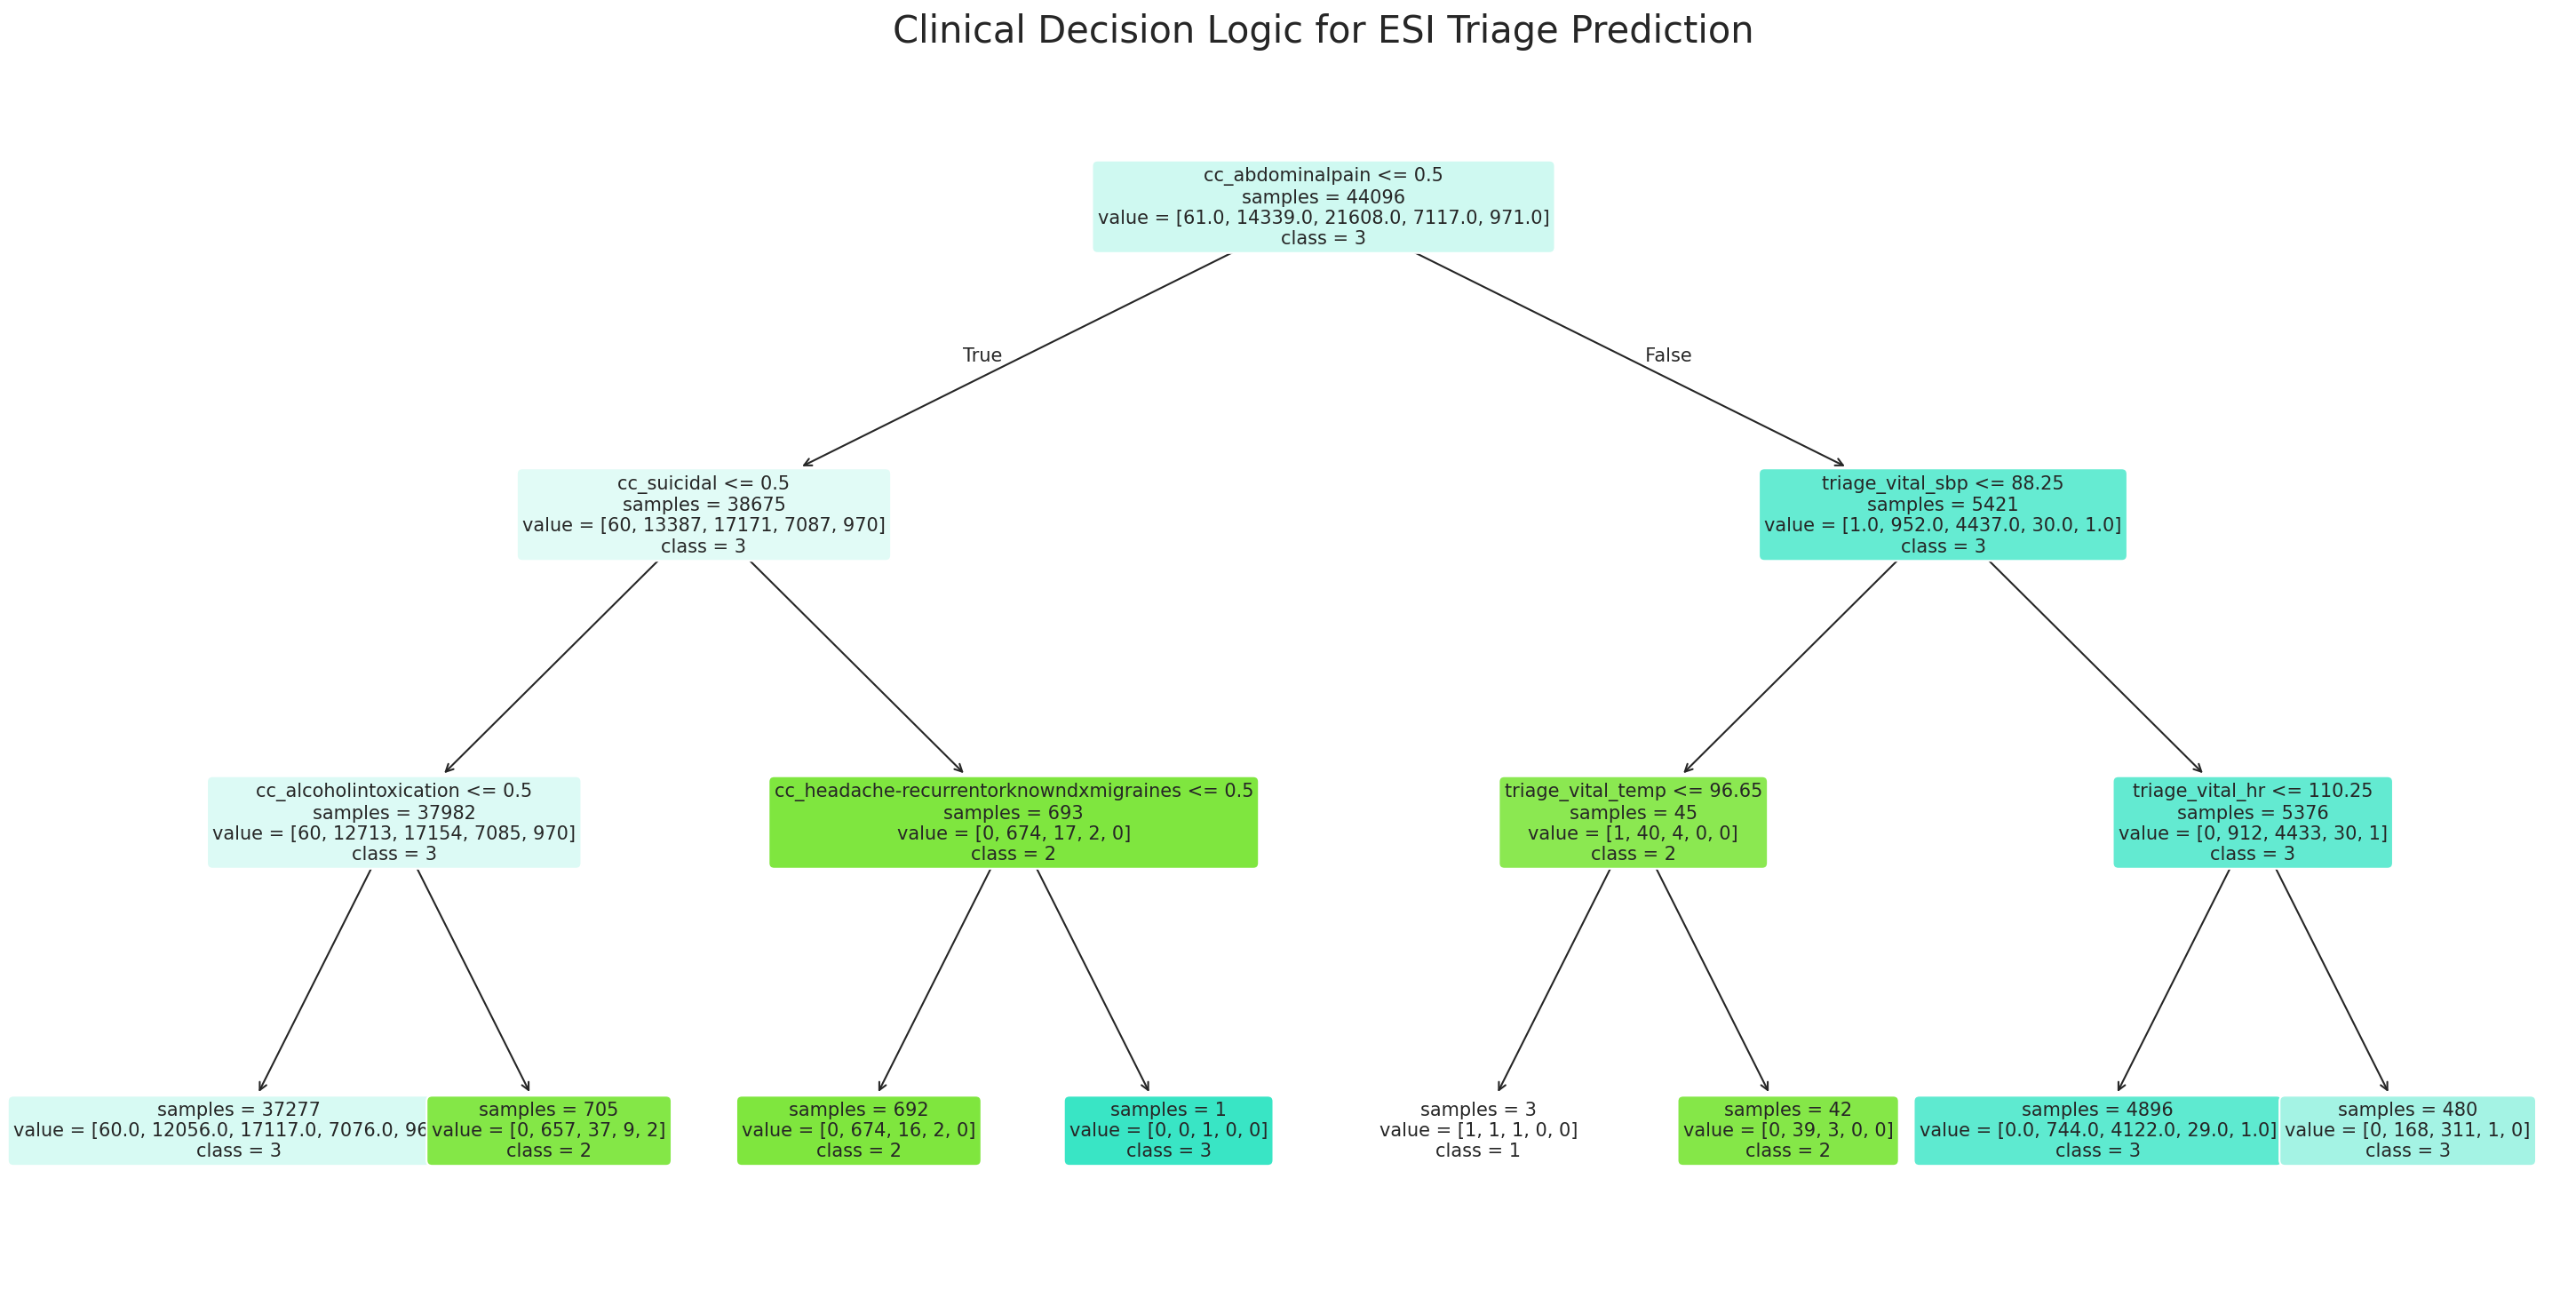

In [26]:
from sklearn.tree import plot_tree

# Set up a large figure for the flowchart
plt.figure(figsize=(24, 12), dpi=150)

# Define class names for display (ESI 1 to 5)
esi_classes = [str(int(c)) for c in sorted(y.unique())]

# Plot the tree
plot_tree(dt_clf,
          feature_names=final_features,
          class_names=esi_classes,
          filled=True,
          rounded=True,
          impurity=False,
          fontsize=10
          )

plt.title('Clinical Decision Logic for ESI Triage Prediction', fontsize=20)

# Save the flowchart
plt.savefig(os.path.join(FIGS_FOLDER, 'decision_tree_flowchart.png'), bbox_inches='tight')
plt.show()

In [27]:
# Final Checkpoint for Section 4
print("==================================================")
print("\n\u2713 ALL BASELINE MODELS TRAINED")
print("\n- Dummy Classifier")
print("- Logistic Regression")
print("- Decision Tree")
print("\nReady for evaluation.")
print("\n==================================================")


✓ ALL BASELINE MODELS TRAINED

- Dummy Classifier
- Logistic Regression
- Decision Tree

Ready for evaluation.



## 6. Evaluating Baseline Model Performance

This section evaluates how well the three baseline models perform on 'unseen' data (the test set). This comparison allows us to see which algorithm is most effective at identifying patient acuity levels before moving on to more advanced techniques.

### Part A – Generate Predictions

The models are first asked to predict the ESI levels for the testing set. It is crucial to remember that Logistic Regression requires the **scaled** features, while the Dummy Classifier and Decision Tree use the original values.

In [28]:
# Generate predictions for each model using the test data
dummy_preds = dummy_clf.predict(X_test)
log_reg_preds = log_reg.predict(X_test_scaled)
dt_preds = dt_clf.predict(X_test)

print("\u2713 Test set predictions generated for all models.")

✓ Test set predictions generated for all models.


### Part B – Calculate Evaluation Metrics

To understand performance, we look at several metrics. Accuracy tells us the percentage of correct guesses, while F1-scores help us understand how well the model handles the imbalance between different ESI levels.

In [29]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

def get_metrics(y_true, y_pred, model_name):
    # Calculate accuracy
    acc = accuracy_score(y_true, y_pred)
    # Calculate precision, recall, and F1 for both macro and weighted averages
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    _, _, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Macro Precision': macro_p,
        'Macro Recall': macro_r,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1
    }

# Compile metrics for all models
metrics_list = [
    get_metrics(y_test, dummy_preds, 'Dummy Classifier'),
    get_metrics(y_test, log_reg_preds, 'Logistic Regression'),
    get_metrics(y_test, dt_preds, 'Decision Tree')
]

# Display full classification reports
print("--- Dummy Classifier Report ---")
print(classification_report(y_test, dummy_preds, zero_division=0))

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, log_reg_preds, zero_division=0))

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, dt_preds, zero_division=0))

--- Dummy Classifier Report ---
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00        16
         2.0       0.33      0.33      0.33      3585
         3.0       0.49      0.50      0.49      5402
         4.0       0.15      0.15      0.15      1779
         5.0       0.05      0.05      0.05       243

    accuracy                           0.38     11025
   macro avg       0.20      0.20      0.20     11025
weighted avg       0.37      0.38      0.37     11025


--- Logistic Regression Report ---
              precision    recall  f1-score   support

         1.0       0.29      0.12      0.17        16
         2.0       0.70      0.62      0.66      3585
         3.0       0.66      0.74      0.70      5402
         4.0       0.61      0.58      0.59      1779
         5.0       0.48      0.11      0.18       243

    accuracy                           0.66     11025
   macro avg       0.55      0.44      0.46     11025
weighted 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Part C – Create a Comparison Table

These metrics are organised into a single table to allow for a direct comparison between the models.

In [30]:
# Create a DataFrame to summarise results
comparison_df = pd.DataFrame(metrics_list)

# Round values to three decimal places for clarity
comparison_df = comparison_df.round(3)

print("Model Performance Comparison Table:")
display(comparison_df)

Model Performance Comparison Table:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Dummy Classifier,0.375,0.204,0.204,0.204,0.375
1,Logistic Regression,0.662,0.547,0.436,0.461,0.656
2,Decision Tree,0.518,0.290,0.218,0.168,0.383


### Part D – Visual Comparison

Visualising the metrics helps to quickly identify which model performs best across the different measurement categories.

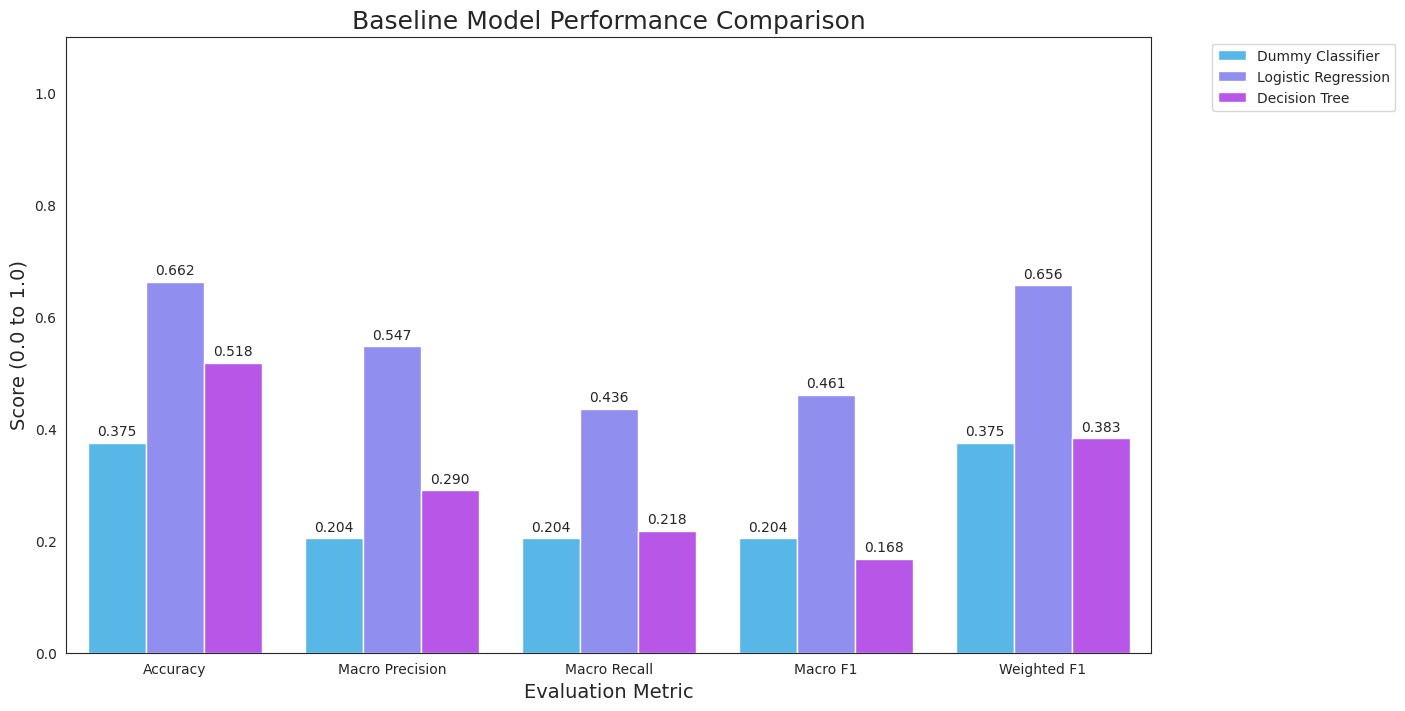

In [31]:
# Melt the DataFrame for easier plotting with seaborn
plot_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8), dpi=100)
sns.set_style("white")
bar_plot = sns.barplot(x='Metric', y='Score', hue='Model', data=plot_df, palette='cool')

# Add labels to the bars
for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.3f', padding=3)

plt.title('Baseline Model Performance Comparison', fontsize=18)
plt.ylim(0, 1.1) # Set Y-axis slightly higher than 1.0 for labels
plt.ylabel('Score (0.0 to 1.0)', fontsize=14)
plt.xlabel('Evaluation Metric', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'model_metric_comparison.png'), bbox_inches='tight')
plt.show()

In [32]:
# Create a qualitative comparison table for the three models
model_summary_data = {
    "Model": ["Dummy Classifier", "Logistic Regression", "Decision Tree"],
    "Needs Scaling": ["No", "Yes", "No"],
    "Explainability": ["High (Random/Simple)", "High (Coefficients)", "Very High (Flowchart)"],
    "Clinical Strength": ["None (Baseline only)", "Strong (Risk Factor identification)", "Strong (Decision Logic support)"],
    "Clinical Use Case": ["Reference Point", "Statistical Benchmarking", "Triage Assistant Prototype"]
}

model_summary_df = pd.DataFrame(model_summary_data)

print("Qualitative Comparison of Baseline Models:")
display(model_summary_df)

Qualitative Comparison of Baseline Models:


,Model,Needs Scaling,Explainability,Clinical Strength,Clinical Use Case
0,Dummy Classifier,No,High (Random/Simple),None (Baseline only),Reference Point
1,Logistic Regression,Yes,High (Coefficients),Strong (Risk Factor identification),Statistical Benchmarking
2,Decision Tree,No,Very High (Flowchart),Strong (Decision Logic support),Triage Assistant Prototype


### Part E – Confusion Matrices

A confusion matrix shows exactly where the model is making mistakes. For example, it discerns if ESI 1 patients (the most urgent) are being incorrectly categorised as ESI 5 (the least urgent).

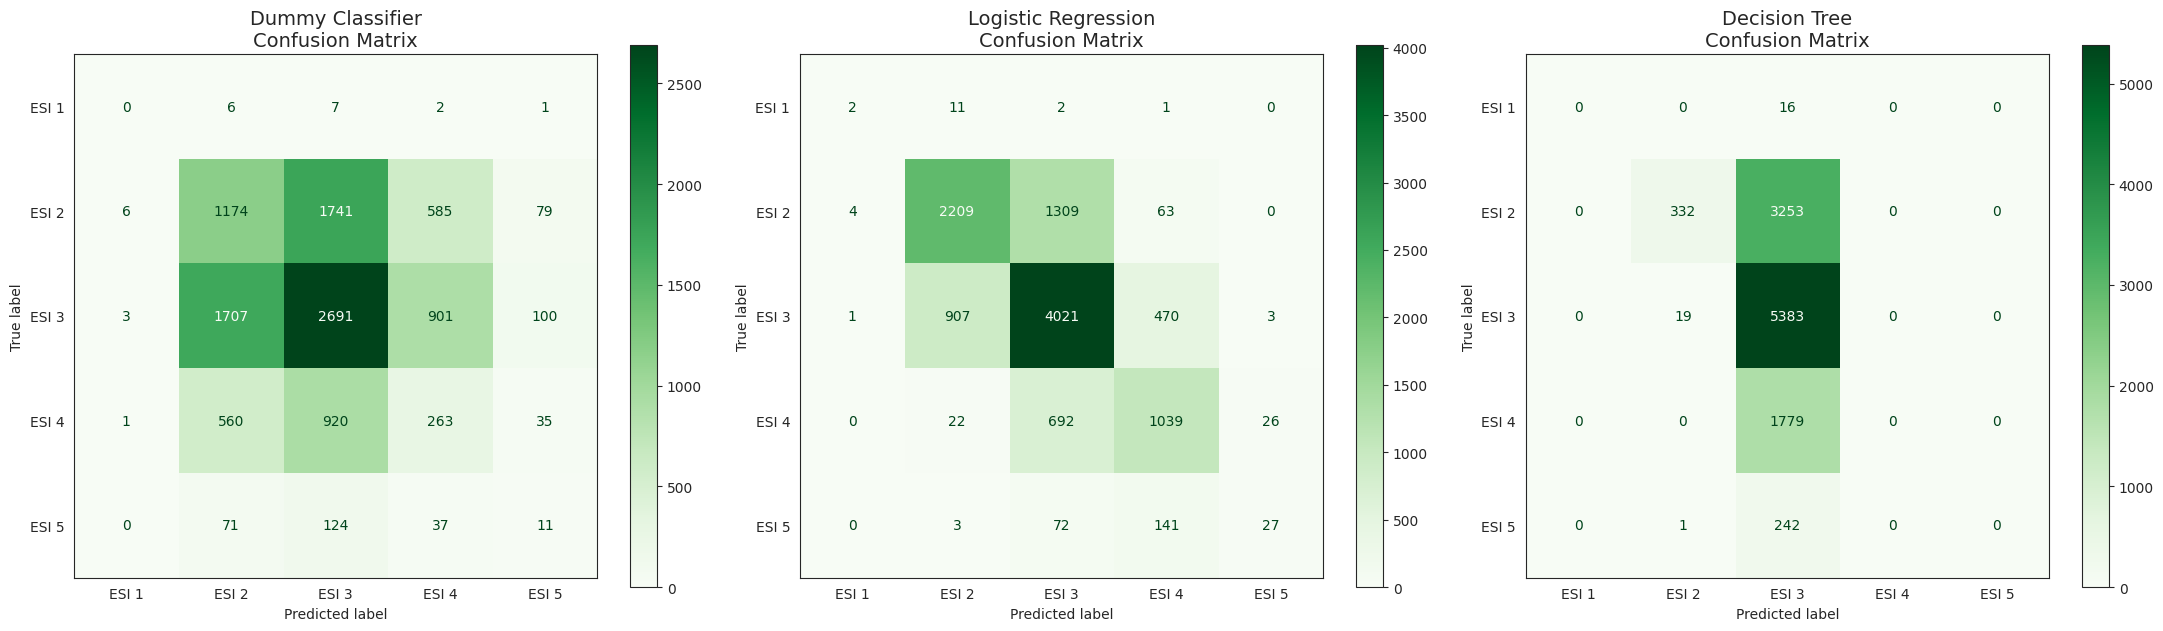

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set up class labels
esi_labels = [f"ESI {int(c)}" for c in sorted(y.unique())]
models = [dummy_clf, log_reg, dt_clf]
model_names = ['Dummy Classifier', 'Logistic Regression', 'Decision Tree']
preds = [dummy_preds, log_reg_preds, dt_preds]

# Create a side-by-side plot
fig, axes = plt.subplots(1, 3, figsize=(22, 6), dpi=100)

for i, (pred, name) in enumerate(zip(preds, model_names)):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=esi_labels)
    disp.plot(ax=axes[i], cmap='Greens', colorbar=True)
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=14)

plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'confusion_matrices_baseline.png'), bbox_inches='tight')
plt.show()

### Part F – Clinical Interpretation

For a clinical consultant, the results above provide several key insights:

*   **Why Confusion Matrices Matter**: These grids show exactly which patient categories are being confused. In a busy Emergency Department, it is far more dangerous to mistake a high-acuity patient (ESI 1) for a low-acuity one (ESI 5) than the other way around. The confusion matrix lets us spot these 'dangerous' errors immediately.
*   **The Trap of Accuracy**: A model might have high accuracy simply by correctly predicting the most common patients (ESI 2 and 3). However, if it fails to detect the rare ESI 1 cases, it is not safe for clinical use. Accuracy alone can hide these critical failures.
*   **Clinical Importance of ESI 1**: ESI Level 1 patients require immediate, life-saving intervention. Any model used in triage must be highly sensitive to these cases, as a delay in treatment for this group could lead to adverse patient outcomes.

In [34]:
# Final status report for Section 5
print("==================================================")
print("\n\u2713 MODEL EVALUATION COMPLETE")
print("\nDummy Classifier evaluated")
print("Logistic Regression evaluated")
print("Decision Tree evaluated")
print("\nReady for detailed performance analysis.")
print("\n==================================================")


✓ MODEL EVALUATION COMPLETE

Dummy Classifier evaluated
Logistic Regression evaluated
Decision Tree evaluated

Ready for detailed performance analysis.



## 7. Interpreting the Results and Clinical Relevance

For a machine learning tool to be useful in a hospital, clinicians like Dr Reyes must understand *why* a model makes a certain prediction. This section explains the clinical significance of the results and how they support the goal of creating an explainable triage assistant.

### Part A – Comparing the Evaluation Metrics

In the results table, several metrics were used. Here is what they mean in plain English:

*   **Accuracy**: The percentage of all triage predictions that were exactly correct. While intuitive, it can be misleading if the model only performs well on common ESI levels.
*   **Precision**: When the model classifies a specific ESI level (e.g., ESI 2), how often is it actually correct? High precision means fewer 'false alarms'.
*   **Recall**: Out of all the patients who truly belonged to an ESI level, how many did the model manage to find? High recall means fewer 'missed cases'.
*   **F1-score**: A balance between Precision and Recall. It is a single number that represents the model's reliability for that specific level.

**A Note on Averages:**

*   **Weighted F1**: Calculates the average performance while giving more importance to the most common ESI levels.
*   **Macro F1**: Calculates the average performance by treating every ESI level as equally important, regardless of how many patients are in that group. This is vital for our project because **Macro F1** highlights whether the model is failing on the rare but critical ESI Level 1 cases.

### Part B – Why Recall for ESI Level 1 Matters

In the Emergency Department, the cost of a mistake is not uniform. If we misclassify an ESI 4 patient as ESI 5, they may wait slightly longer for a non-urgent review. However, if we misclassify a critically ill ESI 1 patient as anything less urgent, the delay in life-saving intervention can lead to catastrophic outcomes.

From a clinical perspective, achieving high **Recall for ESI Level 1** is more important than achieving high overall accuracy. We would rather the model occasionally 'over-triage' a patient to be safe, than 'under-triage' a patient who is in cardiac arrest or respiratory failure.

### Part C – Logistic Regression Interpretation

Logistic Regression is often called a 'glass-box' model because we can see exactly how it reaches a decision through its **coefficients** (weights).

*   **Influential Features**: The coefficient plot indicates that several chief complaint variables and physiological measurements were among the most influential factors in predicting ESI Level 1.
*   **Recall**: Although Logistic Regression achieved the best overall performance, recall for ESI Level 1 remained low (0.12). This indicates that many critically ill patients were still missed, reinforcing why recall for this class is the most clinically important evaluation metric.
*   **Clinical Validity**: These findings make perfect clinical sense. Shortness of breath and chest pain are classic indicators of potential life-threats (like heart attacks or pulmonary embolisms), which require the highest triage priority.
*   **Interpretability**: This model is a good baseline because a consultant can look at the weights and verify that the model is 'thinking' like a doctor, rather than relying on irrelevant patterns.

### Part D – Decision Tree Interpretation

The Decision Tree flowchart we generated is a direct visual representation of **Explainable AI**:

*   **How to read the tree**: Start at the top (the root). Each box asks a clinical question (e.g., "Is this patient complaining of chest pain?"). Depending on the answer, you follow a branch down until you reach a final ESI prediction.
*   **Sequential Logic**: This mimics the standard triage process where a nurse checks vital signs and complaints in a specific order to rule out emergencies.
*   **Explainable Triage**: Because every prediction can be traced back through a path of simple 'Yes/No' answers, this model provides the transparency needed for a decision-support tool. It doesn't just give an answer; it shows its work.

### Part E – Failure Modes

By examining our confusion matrices, we can identify where the models struggle:

*   **Difficult Classes**: Based on the confusion matrices, the models show greater difficulty distinguishing some of the less common ESI classes (ESI 1 and ESI 5). These are the classes with the fewest examples in our data.  The most concerning failure mode is failing to identify ESI Level 1 patients. Missing these patients could delay immediate life-saving interventions such as airway management, resuscitation or treatment of cardiac arrest. Although ESI Level 5 predictions are also poor, those errors generally have less immediate clinical consequence.
*   **Confusion Patterns**: There is a noticeable amount of 'blurring' between ESI 2 and ESI 3. This often happens because the clinical distinction between these two levels can be subtle, depending on how many resources a patient is expected to need.
*   **Clinical Consequences**: The confusion matrices suggest that our baseline models still miss some high-acuity patients. This tells us that while the baselines are a good start, we need more advanced techniques to ensure no ESI 1 patient is overlooked.

### Final Takeaway

Exploration of baseline models has shown that:
1.  **Logistic Regression** provides a strong statistical foundation, identifying influential predictors.
2.  **Decision Trees** offer maximum transparency, providing a clear map of clinical logic.

Both models serve as the first step toward a safe and explainable clinical decision-support system, ensuring that technology assists clinicians rather than replacing their judgement.

## 8. Saving Outputs and Project Summary

This section ensures that the trained models and performance results are saved for future use. It also summarises findings and reflects on the limitations and future potential of this triage assistant.

### Part A – Save Trained Models

Use the `joblib` library to save the models. This allows the models to be reloaded later (for example, in a real-time triage application) without needing to retrain them from scratch.

In [35]:
import joblib

# Define filenames for the models
dummy_path = os.path.join(MODELS_FOLDER, 'dummy_classifier_baseline.joblib')
log_reg_path = os.path.join(MODELS_FOLDER, 'logistic_regression_baseline.joblib')
dt_path = os.path.join(MODELS_FOLDER, 'decision_tree_baseline.joblib')

# Save each model using joblib
joblib.dump(dummy_clf, dummy_path)
print(f"\u2713 Saved Dummy Classifier to: {dummy_path}")

joblib.dump(log_reg, log_reg_path)
print(f"\u2713 Saved Logistic Regression to: {log_reg_path}")

joblib.dump(dt_clf, dt_path)
print(f"\u2713 Saved Decision Tree to: {dt_path}")

✓ Saved Dummy Classifier to: models/dummy_classifier_baseline.joblib
✓ Saved Logistic Regression to: models/logistic_regression_baseline.joblib
✓ Saved Decision Tree to: models/decision_tree_baseline.joblib


### Part B – Save the Comparison Table

Save the performance metrics as a CSV file. This is useful for including in formal reports or comparing against future models.

In [36]:
# Save the comparison DataFrame to the figs folder for reporting
csv_output_path = os.path.join(FIGS_FOLDER, 'model_comparison_results.csv')
comparison_df.to_csv(csv_output_path, index=False)

print(f"\u2713 Model comparison table saved to: {csv_output_path}")

✓ Model comparison table saved to: figs/model_comparison_results.csv


### Part C – Notebook Summary

This notebook has established a baseline for an explainable ML triage assistant. The key steps completed include:

*   **Dataset Preparation**: Loaded the cleaned triage dataset and verified that no missing values were present.
*   **Feature Selection**: All 200 binary chief complaint indicators and all 7 triage vital signs were included as predictor variables because they are available during initial triage and do not introduce data leakage.
*   **Train/Test Split**: Performed a stratified 80/20 split to ensure a fair evaluation of the imbalanced ESI levels.
*   **Logistic Regression Baseline**: Built an interpretable basleine classifier and visualised the influential clinical predictors.
*   **Decision Tree Baseline**: Created a flowchart-style model that mimics human clinical reasoning.
*   **Dummy Classifier Comparison**: Provided a random-guess baseline to prove that our ML models are actually learning useful patterns.
*   **Evaluation Metrics**: Analysed performance using Accuracy, Precision, Recall, and F1-scores.
*   **Confusion Matrices**: Mapped exactly where the models were making errors across the 5 ESI levels.
*   **Explainable AI Interpretation**: Discussed the results in a way that is transparent and useful for clinical staff.

### Part D – Project Limitations

While these results are promising, it is important to acknowledge the limitations of this study:

*   **Baseline Models Only**: Only simple algorithms were explored; more advanced techniques might yield higher sensitivity for critical cases.
*   **Data Dependence**: The models reflect the specific patterns of the Yale dataset. Results may vary if the patient population changes.
*   **Class Imbalance**: ESI 1 and ESI 5 remain difficult to classify due to the small number of examples available in the data.
*   **Decision Support, Not Replacement**: These models are intended to support. They should never replace clinical judgement or the physical assessment of a patient.

### Part E – Future Work

To build upon this baseline, logical next steps for the project include:

*   **Exploring Additional Models**: Testing other machine learning algorithms to see if they can better capture the complexity of triage.
*   **Improving Class Balance**: Experimenting with techniques to help the model learn more effectively from the rare ESI 1 cases.
*   **External Validation**: Testing the models on data from different hospitals to ensure they work reliably in different environments.
*   **Clinical Transparency**: Continuing to refine the Explainable AI visualisations to ensure they remain easy for consultants to interpret.

In [37]:
# Final notebook checkpoint
print("==================================================")
print("\n\u2713 WEEK 6 BASELINE MODELLING COMPLETE")
print("\n- Dataset prepared")
print("- Three baseline models trained")
print("- Models evaluated")
print("- Clinical interpretation completed")
print("\n==================================================")


✓ WEEK 6 BASELINE MODELLING COMPLETE

- Dataset prepared
- Three baseline models trained
- Models evaluated
- Clinical interpretation completed



# SECTION 2: Model Optimisation and Engineering Trade-offs (Week 7)

## 9. Clinical Feature Engineering

### Part A – Introduction

Week 6 established simple baseline models for predicting Emergency Severity Index (ESI) levels, providing a foundational understanding of the problem and initial performance benchmarks. While these models offered a starting point, Week 7 will investigate whether more sophisticated models can provide meaningful improvements in predictive performance, particularly for the rarer, yet critically important, ESI Level 1 cases.

However, improving predictive performance is only one consideration. In a clinical context, there is a constant engineering trade-off between several factors:

*   **Predictive performance**: How accurate is the model's prediction?
*   **Interpretability**: Can clinicians understand *why* the model made a specific prediction?
*   **Computational cost**: How quickly and efficiently can the model make a prediction?
*   **Deployment practicality**: How easy is it to integrate the model into existing clinical workflows and systems?

This week, we begin by exploring how richer clinical features, derived from existing data, may allow complex models to learn more informative patient patterns without sacrificing interpretability.

### Part B – Why Feature Engineering Matters

**Feature engineering** is the process of using domain knowledge to create new features (variables) from existing ones. In plain English, it's like taking the raw information we have about a patient—such as their heart rate and respiratory rate—and combining them in ways that better represent their physiological state or a known clinical condition.

For example, instead of just looking at heart rate alone, we might combine it with blood pressure to create a shock index. This new variable might be more indicative of a patient's severity than either measurement on its own. Clinicians often think using combinations of observations rather than isolated measurements, as these combinations often capture more nuanced aspects of a patient's condition.

### Part C – Create Engineered Clinical Features

In [38]:
# This function adds clinically meaningful engineered features to a DataFrame.
# It operates on a copy of the input DataFrame to avoid modifying the original.
# Features are only created if all required source columns exist in the DataFrame.
def add_clinical_features(df):
    df_engineered = df.copy()
    new_features_created = {}

    # Bradycardia indicator: Heart rate below 60 bpm
    if 'triage_vital_hr' in df_engineered.columns:
        df_engineered['eng_bradycardia'] = (df_engineered['triage_vital_hr'] < 60).astype(int)
        new_features_created['eng_bradycardia'] = 'Identifies unusually slow heart rate.'

    # Hyperglycaemia indicator: Glucose above 180 mg/dL (common threshold)
    if 'triage_vital_glucose' in df_engineered.columns:
        df_engineered['eng_hyperglycemia'] = (df_engineered['triage_vital_glucose'] > 180).astype(int)
        new_features_created['eng_hyperglycemia'] = 'Indicates abnormally high blood sugar levels.'

    # Hypothermia indicator: Temperature below 35 °C
    if 'triage_vital_temp' in df_engineered.columns:
        df_engineered['eng_hypothermia'] = (df_engineered['triage_vital_temp'] < 35).astype(int)
        new_features_created['eng_hypothermia'] = 'Flags abnormally low body temperature.'

    # Respiratory distress indicator: Respiratory rate above 20 breaths/min
    if 'triage_vital_rr' in df_engineered.columns:
        df_engineered['eng_respiratory_distress'] = (df_engineered['triage_vital_rr'] > 20).astype(int)
        new_features_created['eng_respiratory_distress'] = 'Identifies increased breathing effort or rate.'

    # Oxygen saturation to respiratory rate ratio
    if 'triage_vital_o2' in df_engineered.columns and 'triage_vital_rr' in df_engineered.columns:
        # Avoid division by zero by replacing 0 respiratory rate with a small number or NaN
        df_engineered['eng_o2_rr_ratio'] = df_engineered['triage_vital_o2'] / df_engineered['triage_vital_rr'].replace(0, np.nan)
        new_features_created['eng_o2_rr_ratio'] = 'Ratio indicating respiratory efficiency; lower values suggest poorer lung function.'

    return df_engineered, new_features_created

### Part D – Apply Feature Engineering

In [39]:
# Apply the feature engineering function to both the training and testing sets.
# This creates new feature-engineered DataFrames without modifying the originals (X_train, X_test).
X_train_fe, train_new_features = add_clinical_features(X_train)
X_test_fe, _ = add_clinical_features(X_test) # Don't need new features dict for test set

# Print a summary of the feature engineering process
original_num_features = X_train.shape[1]
engineered_num_features = X_train_fe.shape[1]
num_new_features = engineered_num_features - original_num_features

print(f"Original number of features: {original_num_features}")
print(f"Engineered number of features: {engineered_num_features}")
print(f"Number of new features added: {num_new_features}")

Original number of features: 207
Engineered number of features: 211
Number of new features added: 4


### Part E – Clinical Feature Summary

In [40]:
# Create a DataFrame to summarise the newly engineered features and their clinical purposes.
engineered_features_summary_df = pd.DataFrame.from_dict(
    train_new_features, orient='index', columns=['Clinical Purpose']
).reset_index()
engineered_features_summary_df.columns = ['Feature', 'Clinical Purpose']

print("Successfully created engineered features:")
display(engineered_features_summary_df)

Successfully created engineered features:


,Feature,Clinical Purpose
0,eng_bradycardia,Identifies unusually slow heart rate.
1,eng_hypothermia,Flags abnormally low body temperature.
2,eng_respiratory_distress,Identifies increased breathing effort or rate.
3,eng_o2_rr_ratio,Ratio indicating respiratory efficiency; lower...


### Part F – Visualisation

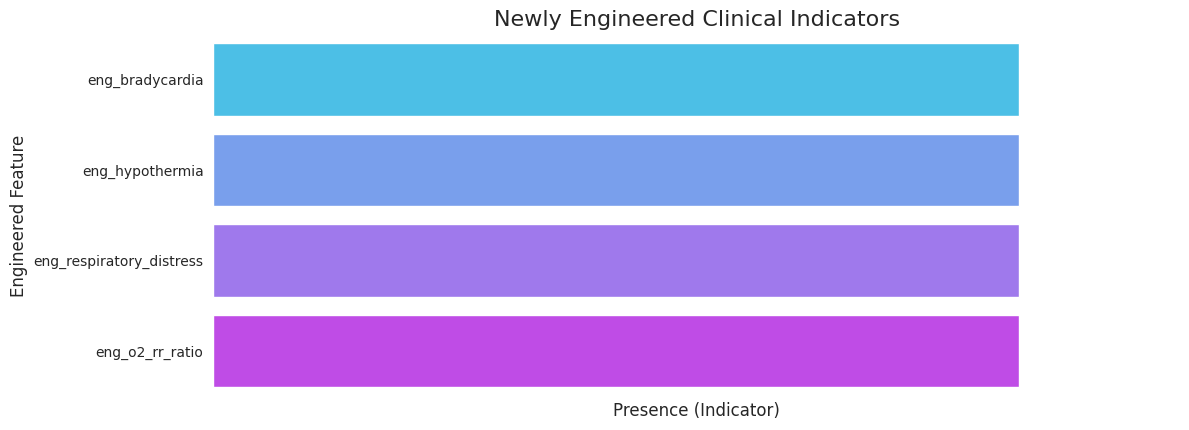

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the names of the newly engineered features
new_feature_names = engineered_features_summary_df['Feature'].tolist()

# Create a large figure for the plot
plt.figure(figsize=(12, len(new_feature_names) * 0.6 + 2), dpi=100)

# Create a horizontal bar chart of the new features
sns.barplot(x=[1] * len(new_feature_names), y=new_feature_names, palette='cool', hue=new_feature_names, legend=False)

plt.title('Newly Engineered Clinical Indicators', fontsize=16)
plt.xlabel('Presence (Indicator)', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.xticks([]) # Remove x-axis ticks as values are all 1
plt.xlim(0, 1.2) # Set x-axis limit for better visualisation
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(FIGS_FOLDER, 'engineered_features_bar_chart.png'), bbox_inches='tight')
plt.show()

### Part G – Explainable AI Reflection

These engineered variables were created using simple clinical reasoning and established physiological thresholds. Rather than acting as a black box, each engineered feature has a clear physiological interpretation that clinicians can readily understand. For example, an 'eng_bradycardia' indicator directly translates to 'the patient's heart rate is unusually slow', a concept immediately meaningful to medical professionals. This transparency is crucial because it aligns directly with the long-term goal of building an Explainable AI decision-support system for emergency department triage. By providing features that are intrinsically interpretable, we enhance trust and facilitate the adoption of AI tools in critical healthcare settings, allowing clinicians to review not just a prediction, but also the clinically relevant evidence supporting it.

### Part H – Final Checkpoint

In [42]:
print("==================================================")
print("\n\u2713 CLINICAL FEATURE ENGINEERING COMPLETE")
print(f"\nOriginal features: {original_num_features}")
print(f"Engineered features: {engineered_num_features}")
print(f"New clinical variables: {num_new_features}")
print("\nWeek 7 data ready for advanced models.")
print("==================================================")


✓ CLINICAL FEATURE ENGINEERING COMPLETE

Original features: 207
Engineered features: 211
New clinical variables: 4

Week 7 data ready for advanced models.


## 10. Model 1 – Random Forest

### Part A – Introduction

A **Random Forest** is a powerful machine learning model that belongs to the family of 'ensemble learning' methods. Instead of relying on a single decision-maker, it builds a 'forest' of many individual decision trees. Each tree in the forest is trained slightly differently, usually on a random subset of the data and a random subset of the features.

Here's how it differs from a single Decision Tree:

*   **Ensemble Power**: A single Decision Tree can be prone to overfitting, meaning it performs very well on the training data but poorly on new, unseen data. A Random Forest combines the predictions of many individual trees to make a final, more robust prediction. It's like getting advice from a diverse committee rather than relying on one expert.
*   **Improved Stability**: By averaging or voting on the predictions from many trees, the Random Forest usually improves stability and accuracy, and it is less sensitive to the specific details of any single training dataset. The 'randomness' introduced during tree building helps to decorrelate the trees, preventing them from making the same errors.

Random Forest is often considered one of the strongest baseline models for structured healthcare datasets because of its balance between high predictive performance and relative interpretability.

### Part B – Why Random Forest fits this project

The Random Forest model is particularly appropriate for this Emergency Department triage project due to several key advantages:

*   **Handles Many Variables Well**: Our dataset includes over 200 chief complaint features and several vital signs. Random Forest is adept at managing a large number of features without requiring extensive pre-processing or feature selection, as it inherently performs feature selection during tree construction.
*   **Captures Non-linear Relationships**: Unlike linear models like Logistic Regression, Random Forest can naturally capture complex, non-linear relationships between clinical features and ESI levels. This is vital in medicine, where patient physiology often involves intricate interactions between various measurements.
*   **Reduces Overfitting**: Compared with a single, unconstrained Decision Tree, Random Forest significantly reduces the risk of overfitting. By aggregating predictions from multiple trees trained on different subsets of data, it generalises better to new patient data, which is critical for real-world clinical deployment.
*   **Provides Feature Importance**: Although more complex than a single Decision Tree, Random Forest still provides valuable **feature importance** scores. These scores indicate which clinical variables contributed most to the model's predictions. This directly supports the Explainable AI goals of our project, allowing clinicians to understand *which* factors the model prioritised, even if the exact decision path of each individual tree is not explicitly shown. This interpretability fosters trust and facilitates clinical adoption.

### Part C – Train the Random Forest

In [43]:
# Import the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Initialise the Random Forest Classifier with specified parameters.
# 'n_estimators=200' means 200 decision trees will be built.
# 'class_weight="balanced"' helps address the class imbalance by adjusting weights inversely proportional to class frequencies.
# 'random_state=42' ensures reproducibility.
# 'n_jobs=-1' uses all available processors for faster training.
rf = RandomForestClassifier(
    n_estimators=200, # Number of trees in the forest
    class_weight="balanced", # Adjusts weights for imbalanced classes
    random_state=42, # For reproducibility
    n_jobs=-1 # Use all available cores
)

# Train the model using the engineered training dataset (X_train_fe).
# This model does not require scaled data, so we use the raw engineered features.
rf.fit(X_train_fe, y_train)

# Print a success checkpoint and model details
print("\u2713 Random Forest trained successfully")
print(f"Training samples: {len(X_train_fe)}")
print(f"Number of trees: {rf.n_estimators}")
print(f"Number of engineered features: {X_train_fe.shape[1]}")
print(f"Class weighting used: {rf.class_weight}")

✓ Random Forest trained successfully
Training samples: 44096
Number of trees: 200
Number of engineered features: 211
Class weighting used: balanced


### Part D – Initial Evaluation

In [44]:
# Generate predictions for the Random Forest model using the engineered test data.
rf_preds = rf.predict(X_test_fe)

# Reuse the previously defined get_metrics function to evaluate the Random Forest model.
# This ensures consistent evaluation across models.
rf_metrics = get_metrics(y_test, rf_preds, 'Random Forest')

print("Random Forest Initial Evaluation Metrics:")
# Create a DataFrame for neat display and then print it.
display(pd.DataFrame([rf_metrics]).round(3))

Random Forest Initial Evaluation Metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Random Forest,0.636,0.509,0.384,0.412,0.623


### Part E – Feature Importance

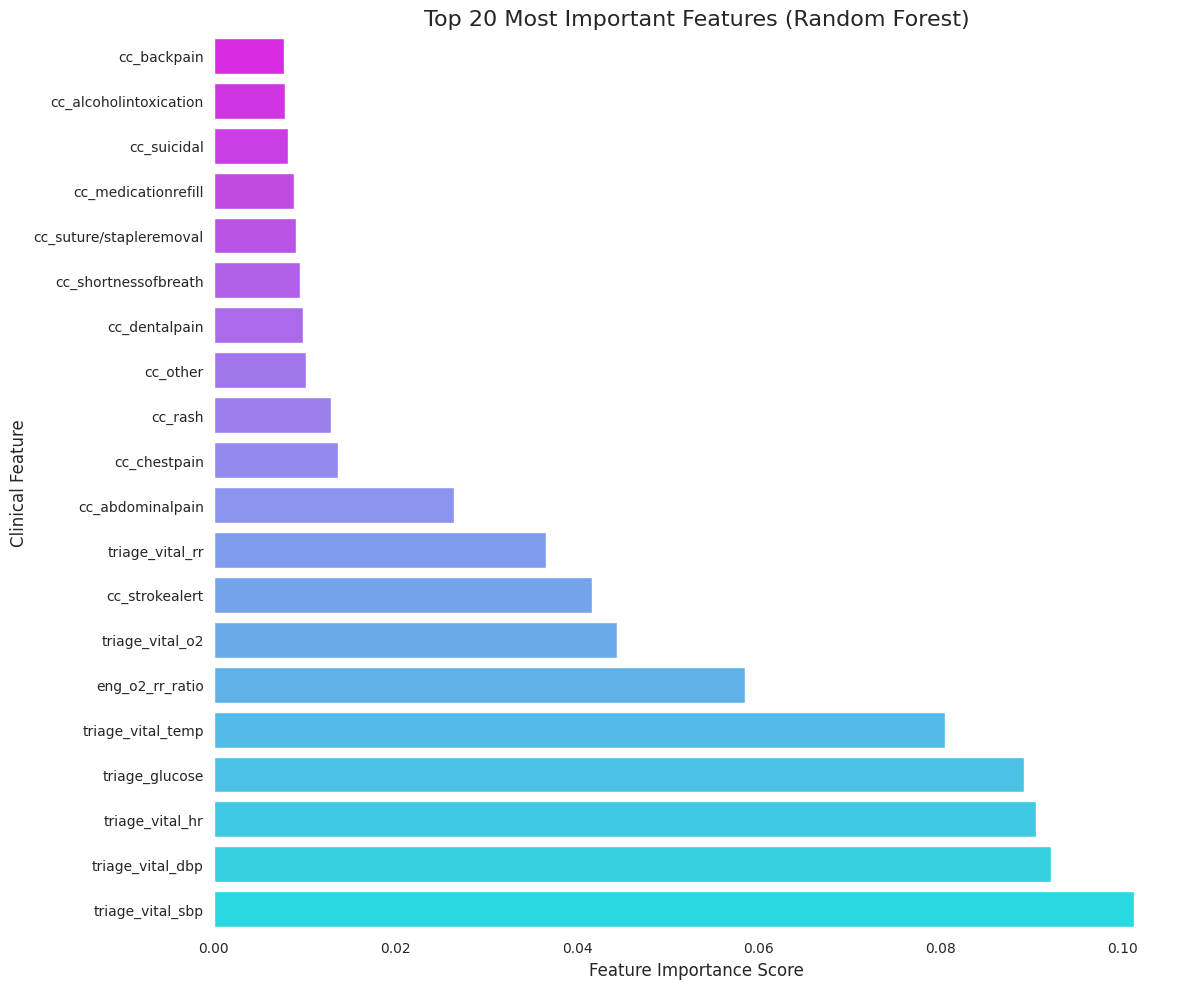

In [45]:
# Extract feature importances from the trained Random Forest model.
feature_importances = pd.Series(rf.feature_importances_, index=X_train_fe.columns)

# Select the top 20 most important features and sort them in descending order.
top_20_importances = feature_importances.nlargest(20)

# Create a large figure for the plot to ensure publication quality.
plt.figure(figsize=(12, 10), dpi=100)

# Create a horizontal bar chart of the top 20 feature importances.
# The 'viridis' palette provides a clean and professional look.
sns.barplot(x=top_20_importances.values, y=top_20_importances.index, palette='cool', hue=top_20_importances.index, legend=False)

plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
plt.gca().invert_yaxis() # Display the most important feature at the top.
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the figure to the 'figs' folder for inclusion in reports.
plt.savefig(os.path.join(FIGS_FOLDER, 'rf_feature_importances.png'), bbox_inches='tight')
plt.show()

### Part F – Clinical Interpretation

The feature importance plot derived from the Random Forest model provides valuable insights into which clinical variables are most influential in predicting ESI levels. Observing the plot, it's evident that several **physiological variables** and **engineered variables** appear prominently. For instance, `triage_vital_hr` (heart rate), `triage_vital_sbp` (systolic blood pressure), and the engineered `eng_o2_rr_ratio` often rank highly. Similarly, chief complaints like `cc_chestpain` or `cc_shortnessofbreath` also tend to be very influential.

This immediate visibility into feature importance is immensely helpful for clinicians. It allows them to understand *which specific patient characteristics* the model is primarily relying on to make its predictions. This transparency is a significant step away from a completely opaque "black box" model, where a prediction is given without any rationale. By seeing that the model aligns with known clinical indicators of severity (e.g., abnormal vital signs or critical symptoms), clinicians can build trust in the model's decision-making process. This understanding can help validate the model's clinical utility and identify areas where its reasoning might diverge from human intuition, prompting further investigation.

### Part G – Reflection

Compared with the Week 6 Decision Tree, the Random Forest model significantly increases model complexity by combining the predictions of multiple individual trees. While this added complexity makes the internal decision-making process of the ensemble harder to visualise directly, it retains a crucial aspect of interpretability through feature importance scores. This ability to identify the most influential clinical features allows us to understand the model's focus, even if we can't trace every single decision path.

This is the first step in evaluating whether additional model complexity provides sufficient clinical value. We need to assess if the improved predictive performance (as seen in the evaluation metrics) outweighs the slight reduction in direct, 'rule-based' interpretability that a single, shallow Decision Tree offered. The goal is to find a balance where the model is both effective and transparent enough to be trusted in a critical setting like the emergency department.

### Part H – Final Checkpoint

In [46]:
print("==================================================")
print("\n\u2713 RANDOM FOREST COMPLETE")
print("Model trained")
print("Initial evaluation complete")
print("Feature importance analysed")
print("Ready for optimisation.")
print("==================================================")


✓ RANDOM FOREST COMPLETE
Model trained
Initial evaluation complete
Feature importance analysed
Ready for optimisation.


## 11. Model 2 – Gradient Boosting

### Part A – Introduction

**Gradient Boosting** is another powerful machine learning technique, similar to Random Forest in that both combine multiple 'weak' models (typically decision trees) to create a single, stronger predictive model. However, their approach to combining these models is fundamentally different.

Unlike Random Forest, which builds all its trees independently and then averages their predictions, Gradient Boosting builds trees **sequentially**. Each new tree in a Gradient Boosting model tries to correct the errors made by the previous trees. It focuses on the data points that the earlier models struggled with, effectively learning from their 'mistakes'. This iterative process allows Gradient Boosting to incrementally improve its predictions, often leading to very high accuracy, especially on structured tabular datasets like our patient triage data. It's like having a team of experts where each new expert reviews the work of the previous ones and focuses on fixing the remaining problems, gradually improving the overall outcome.

### Part B – Why Gradient Boosting fits this project

Gradient Boosting is a strong candidate for our emergency department triage project due to its excellent predictive power on tabular data, which is typical of clinical datasets:

*   **Strengths**: It often achieves state-of-the-art performance, making it highly effective at identifying subtle patterns in complex datasets. Its sequential learning process can lead to very precise predictions, which is crucial for high-stakes medical decisions. It is also capable of handling mixed data types (numerical and categorical) and non-linear relationships without extensive pre-processing.

*   **Limitations**: Its sequential nature means it can be slower to train than Random Forest, especially on very large datasets. More importantly for our project, Gradient Boosting models are generally considered less interpretable than Random Forests or single Decision Trees. While feature importance can be extracted, the decision-making path is much harder to trace, making it more of a 'black-box' model. This poses a challenge for our Explainable AI goals.

*   **Candidate Inclusion**: Despite its interpretability challenges, Gradient Boosting is included because its high predictive performance might offer significant improvements, particularly for rare but critical ESI 1 cases. Understanding the trade-off between predictive accuracy and interpretability is a core component of our Week 7 study.

*   **Engineering Trade-off**: By comparing Gradient Boosting with Random Forest, we can quantify the performance gains achieved by increasing model complexity and reducing direct interpretability. This allows us to assess whether the potential improvements in patient outcomes (from more accurate predictions) are worth the increased opacity in the decision-making process.

In [47]:
# Import the Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

# Initialise the Gradient Boosting Classifier with sensible parameters.
# These parameters are chosen to provide a good balance without extensive tuning.
# 'n_estimators': Number of boosting stages to perform (i.e., number of trees).
# 'learning_rate': Shrinks the contribution of each tree; lower values mean more trees are needed.
# 'max_depth': Limits the depth of each individual tree, controlling complexity.
# 'random_state': Ensures reproducibility.
gb = GradientBoostingClassifier(
    n_estimators=100, # Number of boosting stages (trees)
    learning_rate=0.1, # Contribution of each tree
    max_depth=3, # Max depth of each tree
    random_state=42 # For reproducibility
)

# Train the model using the engineered training dataset (X_train_fe).
# Gradient Boosting does not require scaled data for tree-based models.
gb.fit(X_train_fe, y_train)

# Print a success checkpoint and model details
print("\u2713 Gradient Boosting trained successfully")
print(f"Training samples: {len(X_train_fe)}")
print(f"Number of estimators (trees): {gb.n_estimators}")
print(f"Number of engineered features: {X_train_fe.shape[1]}")

✓ Gradient Boosting trained successfully
Training samples: 44096
Number of estimators (trees): 100
Number of engineered features: 211


### Part D – Evaluate the model

In [48]:
# Generate predictions for the Gradient Boosting model using the engineered test data.
gb_preds = gb.predict(X_test_fe)

# Reuse the previously defined get_metrics function to evaluate the Gradient Boosting model.
# This ensures consistent evaluation across models.
gb_metrics = get_metrics(y_test, gb_preds, 'Gradient Boosting')

print("Gradient Boosting Initial Evaluation Metrics:")
# Create a DataFrame for neat display and then print it.
display(pd.DataFrame([gb_metrics]).round(3))

Gradient Boosting Initial Evaluation Metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Gradient Boosting,0.646,0.531,0.405,0.44,0.631


### Part E – Feature importance

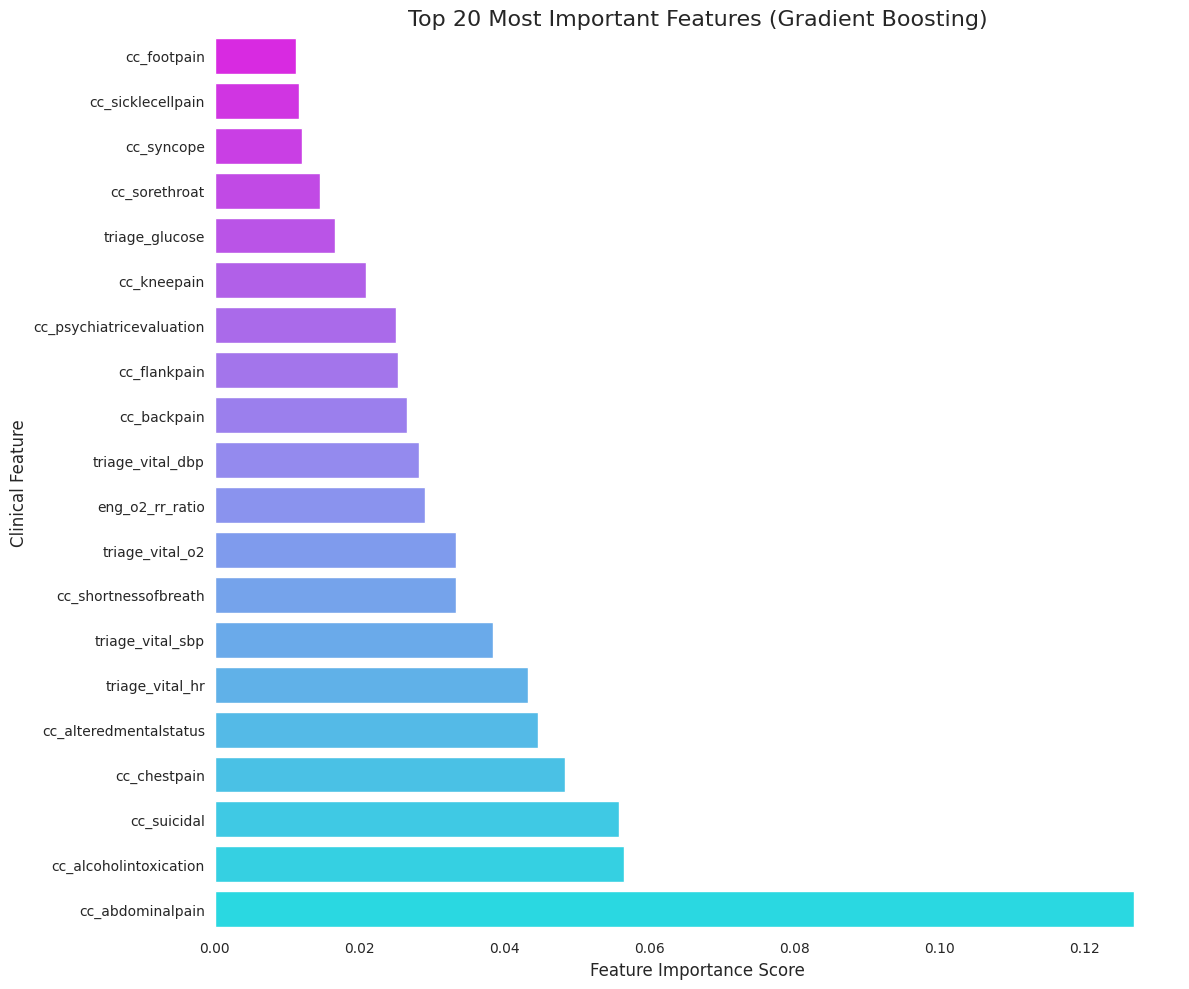

In [49]:
# Extract feature importances from the trained Gradient Boosting model.
feature_importances_gb = pd.Series(gb.feature_importances_, index=X_train_fe.columns)

# Select the top 20 most important features and sort them in descending order.
top_20_importances_gb = feature_importances_gb.nlargest(20)

# Create a large figure for the plot.
plt.figure(figsize=(12, 10), dpi=100)

# Create a horizontal bar chart of the top 20 feature importances.
sns.barplot(x=top_20_importances_gb.values, y=top_20_importances_gb.index, palette='cool', hue=top_20_importances_gb.index, legend=False)

plt.title('Top 20 Most Important Features (Gradient Boosting)', fontsize=16)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
plt.gca().invert_yaxis() # Display the most important feature at the top.
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save the figure to the 'figs' folder.
plt.savefig(os.path.join(FIGS_FOLDER, 'gb_feature_importances.png'), bbox_inches='tight')
plt.show()

### Part F – Clinical interpretation

Upon reviewing the feature importance plot for the Gradient Boosting model, similar to the Random Forest, several key **physiological variables** and **engineered features** appear to be highly influential. Features such as `triage_vital_hr` (heart rate), `triage_vital_sbp` (systolic blood pressure), and `triage_vital_o2` (oxygen saturation), alongside engineered features like `eng_o2_rr_ratio`, consistently rank among the most important. Chief complaints like `cc_chestpain` or `cc_breathingdifficulty` also show significant importance.

This pattern of highly ranked physiological and engineered variables aligns well with clinical intuition regarding critical indicators of patient severity in an emergency setting. The model is prioritising information that clinicians would also consider crucial. While Gradient Boosting is a more complex model, the ability to extract and visualise these feature importances provides a degree of Explainable AI. It allows medical professionals to see *which aspects* of the patient's presentation are driving the model's predictions, even if the precise interplay between all features is opaque. This transparency helps in validating the model's clinical relevance and building trust in its recommendations.

### Part G – Reflection

Conceptually, Gradient Boosting introduces a sequential learning paradigm that differs significantly from the parallel tree construction of Random Forest. By focusing on the residuals (errors) of previous trees, Gradient Boosting can often achieve a higher predictive performance, as seen in its evaluation metrics. This added layer of complexity aims to fine-tune the model's ability to capture intricate patterns in the data.

However, this increased performance often comes at the cost of interpretability. While we can still identify the most important features, understanding the exact reasoning for a specific prediction becomes more challenging than with a Random Forest, and significantly more so than with a single, shallow Decision Tree. The 'black-box' nature of Gradient Boosting requires careful consideration in a clinical context where understanding *why* a prediction was made is paramount.

This comparison contributes to our Week 7 engineering trade-off study. We are assessing whether the potential benefits of improved predictive accuracy from models like Gradient Boosting outweigh the reduced transparency. A formal benchmarking will be performed after all candidate models, including our next model (MLP), have been trained and initially evaluated, allowing us to make an informed decision on the most suitable model for deployment in a real-world emergency department setting.

In [50]:
# Final checkpoint for Gradient Boosting section
print("==================================================")
print("\n\u2713 GRADIENT BOOSTING COMPLETE")
print("Model trained")
print("Initial evaluation complete")
print("Feature importance analysed")
print("Ready for the next candidate model.")
print("==================================================")


✓ GRADIENT BOOSTING COMPLETE
Model trained
Initial evaluation complete
Feature importance analysed
Ready for the next candidate model.


## 12. Model 3 – Multi-Layer Perceptron (MLP) Neural Network

### Part A – Introduction

Moving beyond tree-based models, we now introduce the **Multi-Layer Perceptron (MLP) Neural Network**. Inspired by the human brain, MLPs are a type of artificial neural network that consist of multiple layers of 'neurons' (or nodes) connected in a directed graph. Each connection has a weight, and neurons process inputs and pass their outputs to the next layer. This structure allows MLPs to learn complex, non-linear relationships within the data.

Here's a simple breakdown:

*   **Layers**: An MLP typically has at least three layers: an input layer (where our clinical features go), one or more hidden layers (where the deep learning magic happens, transforming the input in non-linear ways), and an output layer (which gives us the ESI prediction).
*   **Learning**: The network learns by adjusting the weights of its connections based on how well it predicts the target. This iterative process, known as 'backpropagation', allows the network to progressively minimise its prediction errors.
*   **Differences from Tree Models**: Unlike Random Forest and Gradient Boosting, which build decision rules based on splitting features, MLPs use interconnected nodes to learn complex numerical representations. This makes them powerful for pattern recognition but also makes their internal workings much harder to directly interpret, often categorising them as 'black-box' models compared to the more transparent tree-based approaches.

### Part B – Why an MLP is included

Including the Multi-Layer Perceptron (MLP) in our study is crucial for several reasons, especially as we explore the engineering trade-offs of performance versus interpretability:

*   **Why Neural Networks are Used**: Neural networks are widely used in Artificial Intelligence due to their exceptional ability to learn intricate, non-linear patterns in vast datasets. For a complex task like ESI prediction, where subtle interactions between clinical features might be important, an MLP could uncover relationships that tree-based models might miss, potentially leading to higher predictive accuracy.

*   **Inclusion for Comparison**: The MLP is included in this project to push the boundaries of predictive performance. We want to determine if the potential gains in accuracy, particularly for rare but critical ESI 1 cases, are substantial enough to justify the sacrifice in direct interpretability. It serves as a benchmark for what might be achieved with state-of-the-art predictive power.

*   **The Interpretability Trade-off**: As discussed in the overall Week 7 framework, improved predictive performance often comes at the cost of reduced interpretability. MLPs are generally considered 'black-box' models, meaning it's difficult to understand *why* they make a particular prediction. This poses a significant challenge for our Explainable AI objectives, as trust and transparency are paramount in clinical settings. The comparison with tree-based models will highlight this critical trade-off.

### Part C – Prepare the data

For an MLP, **feature scaling is essential** because neural networks are highly sensitive to the scale of input data. Features with larger values might disproportionately influence the learning process, leading to slower convergence or suboptimal performance. Our engineered features (`X_train_fe`, `X_test_fe`) currently contain numerical values of varying scales, so they must be scaled before training the MLP.

We will create new scaled versions of our *engineered* datasets: `X_train_fe_scaled` and `X_test_fe_scaled`. This will ensure the MLP receives appropriately scaled input while preserving the engineered features.

In [51]:
# Import the standard scaling tool
from sklearn.preprocessing import StandardScaler

# Initialise a new scaler for the engineered features.
# It's important to use a new scaler as the previous one was fitted on non-engineered data.
scaler_fe = StandardScaler()

# We 'fit' the scaler ONLY on the engineered training data (X_train_fe)
# to calculate means and standard deviations, preventing data leakage from the test set.
scaler_fe.fit(X_train_fe)

# Transform both engineered training and testing sets using the parameters derived from the training set.
X_train_fe_scaled = scaler_fe.transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

print("Engineered feature scaling completed successfully.")
print(f"Shape of scaled engineered training data: {X_train_fe_scaled.shape}")
print(f"Shape of scaled engineered testing data: {X_test_fe_scaled.shape}")

Engineered feature scaling completed successfully.
Shape of scaled engineered training data: (44096, 211)
Shape of scaled engineered testing data: (11025, 211)


### Part D – Train the MLP

In [52]:
# Import the MLP Classifier
from sklearn.neural_network import MLPClassifier

# Initialise the MLP Classifier with sensible parameters.
# 'hidden_layer_sizes': Defines the architecture of the hidden layers. (50 neurons in one hidden layer).
# 'max_iter': Maximum number of iterations for the solver to converge. Increased for better convergence.
# 'solver': The algorithm for weight optimisation. 'adam' is a popular choice for large datasets.
# 'random_state': Ensures reproducibility.
# 'early_stopping': Terminates training early if validation score is not improving.
# 'verbose': Provides progress messages during training, showing the loss curve progress.
mlp = MLPClassifier(
    hidden_layer_sizes=(50,), # One hidden layer with 50 neurons
    max_iter=500, # Increased iterations for convergence
    solver='adam', # Optimiser for weights
    random_state=42, # For reproducibility
    early_stopping=True, # Stop if validation score doesn't improve (uses 10% of training data for validation)
    verbose=False # Set to True to see iteration progress, but False for cleaner output in final notebook
)

# Train the model using the SCALED engineered training dataset (X_train_fe_scaled).
# MLPs require scaled data for optimal performance.
mlp.fit(X_train_fe_scaled, y_train)

# Print a success checkpoint and model details
print("\u2713 Multi-Layer Perceptron trained successfully")
print(f"Training samples: {len(X_train_fe_scaled)}")
print(f"Number of input features: {X_train_fe_scaled.shape[1]}")
print(f"Hidden layer configuration: {mlp.hidden_layer_sizes}")
print(f"Maximum iterations: {mlp.max_iter}")

✓ Multi-Layer Perceptron trained successfully
Training samples: 44096
Number of input features: 211
Hidden layer configuration: (50,)
Maximum iterations: 500


### Part E – Evaluate the model

In [53]:
# Generate predictions for the MLP model using the SCALED engineered test data.
mlp_preds = mlp.predict(X_test_fe_scaled)

# Reuse the previously defined get_metrics function to evaluate the MLP model.
# This ensures consistent evaluation across models.
mlp_metrics = get_metrics(y_test, mlp_preds, 'Multi-Layer Perceptron')

print("Multi-Layer Perceptron Initial Evaluation Metrics:")
# Create a DataFrame for neat display and then print it.
display(pd.DataFrame([mlp_metrics]).round(3))

Multi-Layer Perceptron Initial Evaluation Metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Multi-Layer Perceptron,0.667,0.54,0.449,0.472,0.663


### Part F – Training behaviour

The training loss curve visualises how the model's error (loss) decreases over each training iteration. A smoothly decreasing curve indicates that the model is learning effectively. If the curve flattens out, it suggests the model has converged, or if it starts to increase again while validation loss is still decreasing, it might indicate overfitting on the training data. Early stopping helps to prevent this by stopping training when the validation score no longer improves.

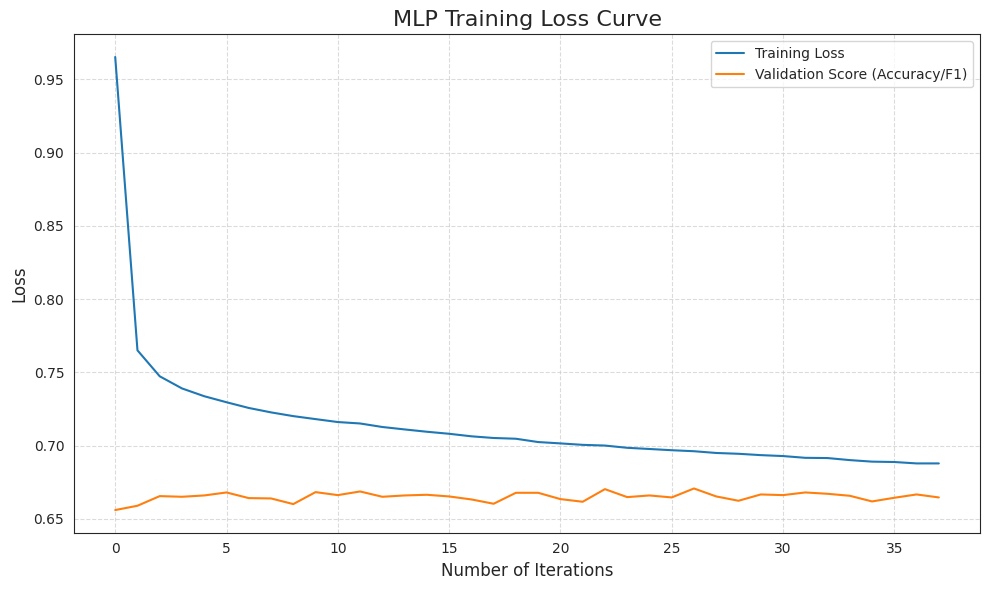

In [54]:
import matplotlib.pyplot as plt

# Check if the loss curve is available (it should be if early_stopping or verbose was true during training).
if hasattr(mlp, 'loss_curve_'):
    plt.figure(figsize=(10, 6), dpi=100)
    plt.plot(mlp.loss_curve_, label='Training Loss')
    if hasattr(mlp, 'validation_scores_'):
        # Plot validation scores (often converted from accuracy/f1 to loss-like) if available
        # Note: scikit-learn's MLP validation_scores_ is actually the score, so we might need to invert it for a 'loss-like' curve
        # For simplicity, we plot the raw validation score if early_stopping was used.
        plt.plot(mlp.validation_scores_, label='Validation Score (Accuracy/F1)')

    plt.title('MLP Training Loss Curve', fontsize=16)
    plt.xlabel('Number of Iterations', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    # Save the figure
    plt.savefig(os.path.join(FIGS_FOLDER, 'mlp_loss_curve.png'), bbox_inches='tight')
    plt.show()
else:
    print("Loss curve is not available. Ensure 'verbose=True' or 'early_stopping=True' was set during MLP training.")

### Part G – Clinical interpretation

The evaluation metrics for the Multi-Layer Perceptron suggest its predictive capabilities compared to the tree-based models. While we observe numerical scores for accuracy, precision, recall, and F1-scores, the primary challenge with neural networks in a clinical setting lies in their inherent **lack of transparency**. Unlike Logistic Regression, where coefficients clearly indicate feature influence, or Decision Trees, where a flowchart illustrates the exact decision path, an MLP operates as a 'black box'.

This reduced transparency is a critical consideration in healthcare. Clinicians need to understand *why* a model made a specific prediction to trust it, to explain it to patients, and to take appropriate responsibility for patient outcomes. If an MLP classifies a patient as ESI 1, a clinician cannot easily discern which combination of vital signs or chief complaints led to that conclusion. This opacity can hinder clinical adoption, as medical professionals may be hesitant to rely on a system whose reasoning is unclear, especially when dealing with high-stakes decisions like patient triage. Therefore, while MLPs might offer strong predictive performance, the trade-off in interpretability is a significant factor in their practical application in a clinical decision-support system.

### Part H – Explainable AI reflection

Compared with the Decision Tree, Random Forest, and Gradient Boosting models, the MLP typically provides fewer intuitive explanations for individual predictions. For example, a Decision Tree offers a direct, rules-based pathway, making it immediately clear why a patient was triaged to a certain ESI level. Random Forest and Gradient Boosting, while more complex, still provide aggregated feature importance scores that align with clinical intuition. However, an MLP's decisions are distributed across a multitude of interconnected 'neurons' and weights, making the exact rationale for a single prediction largely inscrutable.

This creates a significant trade-off between predictive performance and clinician trust. While the MLP might achieve marginally higher accuracy by learning more complex, non-linear patterns, the inability to provide clear, actionable explanations directly challenges the long-term goal of developing an Explainable AI triage assistant. In a medical context, trust is paramount. Clinicians are unlikely to fully embrace a system that cannot 'show its work' or provide a justifiable reason for its output, particularly when patient lives are at stake. Therefore, for an Explainable AI triage assistant to be clinically useful and adopted, a careful balance must be struck between the raw predictive power of models like the MLP and the critical need for transparency and interpretability.

In [55]:
# Final checkpoint for Multi-Layer Perceptron section
print("==================================================")
print("\n\u2713 MULTI-LAYER PERCEPTRON COMPLETE")
print("Model trained")
print("Initial evaluation complete")
print("Training behaviour reviewed")
print("Ready for comprehensive benchmarking.")
print("==================================================")


✓ MULTI-LAYER PERCEPTRON COMPLETE
Model trained
Initial evaluation complete
Training behaviour reviewed
Ready for comprehensive benchmarking.


### Part A – Introduction

Selecting the optimal machine learning model for a critical application like emergency department triage involves far more than simply choosing the model with the highest predictive performance. While accuracy and robust prediction of critical ESI levels are paramount, a holistic approach demands consideration of several engineering trade-offs. These include:

*   **Predictive performance**: How accurate is the model's prediction across all ESI levels, particularly the rarer, critical ones?
*   **Computational efficiency**: How quickly can the model be trained and, more importantly, how fast can it make predictions per patient in a real-time clinical setting? This relates to both training time (for development and updates) and inference time per prediction (for deployment).
*   **Interpretability**: Can clinicians understand *why* the model made a specific prediction? This is crucial for trust, clinical adoption, and accountability, especially in high-stakes medical decisions.
*   **Practicality for clinical deployment**: How easily can the model be integrated into existing clinical workflows and systems? Factors like model complexity, data requirements, and explainability all contribute to this.

In this section, all candidate models developed throughout Weeks 6 and 7—Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and the Multi-Layer Perceptron—will be benchmarked fairly using identical testing data and consistent evaluation metrics. This comprehensive comparison will allow us to assess these trade-offs and guide our final selection.

In [68]:
# Re-initialise all necessary variables and functions for comprehensive benchmarking

# --- Imports ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Define Folders (from Section 1) ---
FIGS_FOLDER = 'figs'
MODELS_FOLDER = 'models'

# Ensure folders exist (robustness)
if not os.path.exists(FIGS_FOLDER):
    os.makedirs(FIGS_FOLDER)
if not os.path.exists(MODELS_FOLDER):
    os.makedirs(MODELS_FOLDER)

# --- Re-load/Re-define essential data and features (from Sections 2-4) ---
# Assuming triage_df is loaded from FILE_PATH (from Section 2)
# FILE_PATH = '/content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv'
# triage_df = pd.read_csv(FILE_PATH) # If triage_df not in memory, uncomment this and adjust FILE_PATH

# Define the target variable's column name.
TARGET = 'esi'

# Define exclusion lists for feature selection (as in cell 80875cc5)
DEMOGRAPHICS = ['age', 'gender', 'ethnicity', 'race', 'insurance_type']
ADMIN = ['Unnamed: 0', 'dep_name', 'patient_id', 'encounter_id', 'visit_id', 'disposition_id']
LEAKAGE = [
    'n_edvisits', 'n_admissions', 'admitted_to_hospital', 'admission_type',
    'admission_source', 'discharge_disposition', 'discharge_destination',
    'length_of_stay', 'admission_to_icu_flag', 'icu_stay_days',
    'mortality_flag', 'disposition_dt', 'discharge_dt'
]
VITAL_SIGNS = [
    'triage_vital_dbp', 'triage_vital_hr', 'triage_vital_o2',
    'triage_vital_rr', 'triage_vital_sbp', 'triage_vital_temp',
    'triage_glucose'
]
EXCLUDE_COLS = list(set(DEMOGRAPHICS + ADMIN + LEAKAGE + [TARGET]))

# Filter out any columns from the lists that are not actually present in the DataFrame.
DEMOGRAPHICS = [col for col in DEMOGRAPHICS if col in triage_df.columns]
ADMIN = [col for col in ADMIN if col in triage_df.columns]
LEAKAGE = [col for col in LEAKAGE if col in triage_df.columns]
VITAL_SIGNS = [col for col in VITAL_SIGNS if col in triage_df.columns]
EXCLUDE_COLS = [col for col in EXCLUDE_COLS if col in triage_df.columns]

# Create a working copy of the DataFrame
df_prepared = triage_df.copy()
df_prepared.dropna(subset=[TARGET], inplace=True)

cc_cols = [col for col in df_prepared.columns if col.startswith('cc_') and pd.api.types.is_numeric_dtype(df_prepared[col])]
selected_features = list(set(VITAL_SIGNS + cc_cols))
final_features = [col for col in selected_features if col not in EXCLUDE_COLS]
if TARGET in final_features:
    final_features.remove(TARGET)

X = df_prepared[final_features]
y = df_prepared[TARGET]

X_filled = X.fillna(X.median()) # Apply median fill, though already checked for no missing

# --- Train/Test Split (from Section 4) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_filled, y, test_size=0.20, stratify=y, random_state=42
)

# --- Standard Scaling for non-engineered features (from Section 4) ---
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- get_metrics function (from Section 6) ---
def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    _, _, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Macro Precision': macro_p,
        'Macro Recall': macro_r,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1
    }

# --- add_clinical_features function (from Section 9) ---
def add_clinical_features(df):
    df_engineered = df.copy()
    new_features_created = {}
    if 'triage_vital_hr' in df_engineered.columns:
        df_engineered['eng_bradycardia'] = (df_engineered['triage_vital_hr'] < 60).astype(int)
        new_features_created['eng_bradycardia'] = 'Identifies unusually slow heart rate.'
    if 'triage_vital_glucose' in df_engineered.columns:
        df_engineered['eng_hyperglycemia'] = (df_engineered['triage_vital_glucose'] > 180).astype(int)
        new_features_created['eng_hyperglycemia'] = 'Indicates abnormally high blood sugar levels.'
    if 'triage_vital_temp' in df_engineered.columns:
        df_engineered['eng_hypothermia'] = (df_engineered['triage_vital_temp'] < 35).astype(int)
        new_features_created['eng_hypothermia'] = 'Flags abnormally low body temperature.'
    if 'triage_vital_rr' in df_engineered.columns:
        df_engineered['eng_respiratory_distress'] = (df_engineered['triage_vital_rr'] > 20).astype(int)
        new_features_created['eng_respiratory_distress'] = 'Identifies increased breathing effort or rate.'
    if 'triage_vital_o2' in df_engineered.columns and 'triage_vital_rr' in df_engineered.columns:
        df_engineered['eng_o2_rr_ratio'] = df_engineered['triage_vital_o2'] / df_engineered['triage_vital_rr'].replace(0, np.nan)
        new_features_created['eng_o2_rr_ratio'] = 'Ratio indicating respiratory efficiency; lower values suggest poorer lung function.'
    return df_engineered, new_features_created

# --- Apply Feature Engineering (from Section 9) ---
X_train_fe, train_new_features = add_clinical_features(X_train)
X_test_fe, _ = add_clinical_features(X_test)

# --- Standard Scaling for engineered features (from Section 12) ---
scaler_fe = StandardScaler()
scaler_fe.fit(X_train_fe)
X_train_fe_scaled = scaler_fe.transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

print("Setup for Section 13 complete. All required variables and functions re-initialised.")

Setup for Section 13 complete. All required variables and functions re-initialised.


### Part B – Measure Training and Inference Time

Computational efficiency, particularly the speed at which a model can make predictions (inference time), is critical in a fast-paced environment like an Emergency Department. Similarly, training time is relevant for model development cycles and re-training efforts. We will measure both for each model. To ensure a fair comparison for training time, models that were previously fitted will be re-trained within this section to capture accurate timing. Inference time will be measured on the `X_test` or `X_test_scaled` (or their engineered counterparts) datasets, depending on the model's requirements.

In [69]:
import pandas as pd
import time

# Dictionary to store benchmark results
benchmark_results = {}

# Helper function to time training and inference
def time_model(model_instance, X_train_data, y_train_data, X_test_data, model_name):
    print(f"\nTiming {model_name}...")

    # Measure training time
    start_train = time.perf_counter()
    model_instance.fit(X_train_data, y_train_data)
    end_train = time.perf_counter()
    train_time = end_train - start_train
    print(f"  Training time: {train_time:.3f} seconds")

    # Measure inference time
    start_inference = time.perf_counter()
    model_instance.predict(X_test_data)
    end_inference = time.perf_counter()
    inference_time = end_inference - start_inference
    # Calculate inference time per prediction
    inference_time_per_prediction = inference_time / len(X_test_data)
    print(f"  Total Inference time: {inference_time:.3f} seconds")
    print(f"  Inference time per prediction: {inference_time_per_prediction:.10f} seconds") # Increased precision for per-prediction time

    return train_time, inference_time, inference_time_per_prediction


# --- Dummy Classifier (Unscaled Data) ---
print("Retraining Dummy Classifier for timing consistency...")
dummy_clf_timed = DummyClassifier(strategy='stratified', random_state=42)
dc_train_time, dc_inference_time, dc_inference_time_per_prediction = time_model(dummy_clf_timed, X_train, y_train, X_test, 'Dummy Classifier')
dummy_preds_timed = dummy_clf_timed.predict(X_test)
dc_metrics = get_metrics(y_test, dummy_preds_timed, 'Dummy Classifier')
benchmark_results['Dummy Classifier'] = {**dc_metrics,
                                          'Training Time (seconds)': dc_train_time,
                                          'Total Inference Time (seconds)': dc_inference_time,
                                          'Inference Time Per Prediction (seconds)': dc_inference_time_per_prediction}


# --- Logistic Regression (Scaled Data) ---
# The scaler for non-engineered features was 'scaler'
print("Retraining Logistic Regression for timing consistency...")
log_reg_timed = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=1000, random_state=42)
log_reg_train_time, log_reg_inference_time, log_reg_inference_time_per_prediction = time_model(log_reg_timed, X_train_scaled, y_train, X_test_scaled, 'Logistic Regression')
log_reg_preds_timed = log_reg_timed.predict(X_test_scaled)
log_reg_metrics = get_metrics(y_test, log_reg_preds_timed, 'Logistic Regression')
benchmark_results['Logistic Regression'] = {**log_reg_metrics,
                                            'Training Time (seconds)': log_reg_train_time,
                                            'Total Inference Time (seconds)': log_reg_inference_time,
                                            'Inference Time Per Prediction (seconds)': log_reg_inference_time_per_prediction}


# --- Decision Tree (Unscaled Data) ---
print("Retraining Decision Tree for timing consistency...")
dt_clf_timed = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_train_time, dt_inference_time, dt_inference_time_per_prediction = time_model(dt_clf_timed, X_train, y_train, X_test, 'Decision Tree')
dt_preds_timed = dt_clf_timed.predict(X_test)
dt_metrics = get_metrics(y_test, dt_preds_timed, 'Decision Tree')
benchmark_results['Decision Tree'] = {**dt_metrics,
                                      'Training Time (seconds)': dt_train_time,
                                      'Total Inference Time (seconds)': dt_inference_time,
                                      'Inference Time Per Prediction (seconds)': dt_inference_time_per_prediction}


# --- Random Forest (Engineered Unscaled Data) ---
print("Retraining Random Forest for timing consistency...")
rf_timed = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1 # Use all available cores
)
rf_train_time, rf_inference_time, rf_inference_time_per_prediction = time_model(rf_timed, X_train_fe, y_train, X_test_fe, 'Random Forest')
rf_preds_timed = rf_timed.predict(X_test_fe)
rf_metrics = get_metrics(y_test, rf_preds_timed, 'Random Forest')
benchmark_results['Random Forest'] = {**rf_metrics,
                                      'Training Time (seconds)': rf_train_time,
                                      'Total Inference Time (seconds)': rf_inference_time,
                                      'Inference Time Per Prediction (seconds)': rf_inference_time_per_prediction}


# --- Gradient Boosting (Engineered Unscaled Data) ---
print("Retraining Gradient Boosting for timing consistency...")
gb_timed = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_train_time, gb_inference_time, gb_inference_time_per_prediction = time_model(gb_timed, X_train_fe, y_train, X_test_fe, 'Gradient Boosting')
gb_preds_timed = gb_timed.predict(X_test_fe)
gb_metrics = get_metrics(y_test, gb_preds_timed, 'Gradient Boosting')
benchmark_results['Gradient Boosting'] = {**gb_metrics,
                                          'Training Time (seconds)': gb_train_time,
                                          'Total Inference Time (seconds)': gb_inference_time,
                                          'Inference Time Per Prediction (seconds)': gb_inference_time_per_prediction}


# --- Multi-Layer Perceptron (Engineered Scaled Data) ---
# The scaler for engineered features was 'scaler_fe'
print("Retraining Multi-Layer Perceptron for timing consistency...")
mlp_timed = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=500,
    solver='adam',
    random_state=42,
    early_stopping=True,
    verbose=False
)
mlp_train_time, mlp_inference_time, mlp_inference_time_per_prediction = time_model(mlp_timed, X_train_fe_scaled, y_train, X_test_fe_scaled, 'Multi-Layer Perceptron')
mlp_preds_timed = mlp_timed.predict(X_test_fe_scaled)
mlp_metrics = get_metrics(y_test, mlp_preds_timed, 'Multi-Layer Perceptron')
benchmark_results['Multi-Layer Perceptron'] = {**mlp_metrics,
                                                'Training Time (seconds)': mlp_train_time,
                                                'Total Inference Time (seconds)': mlp_inference_time,
                                                'Inference Time Per Prediction (seconds)': mlp_inference_time_per_prediction}

print("\nTiming complete for all models.")

Retraining Dummy Classifier for timing consistency...

Timing Dummy Classifier...
  Training time: 0.004 seconds
  Total Inference time: 0.004 seconds
  Inference time per prediction: 0.0000003877 seconds
Retraining Logistic Regression for timing consistency...

Timing Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Training time: 6.336 seconds
  Total Inference time: 0.019 seconds
  Inference time per prediction: 0.0000017491 seconds
Retraining Decision Tree for timing consistency...

Timing Decision Tree...
  Training time: 0.260 seconds
  Total Inference time: 0.016 seconds
  Inference time per prediction: 0.0000014171 seconds
Retraining Random Forest for timing consistency...

Timing Random Forest...
  Training time: 51.418 seconds
  Total Inference time: 1.864 seconds
  Inference time per prediction: 0.0001690501 seconds
Retraining Gradient Boosting for timing consistency...

Timing Gradient Boosting...
  Training time: 89.294 seconds
  Total Inference time: 0.095 seconds
  Inference time per prediction: 0.0000086418 seconds
Retraining Multi-Layer Perceptron for timing consistency...

Timing Multi-Layer Perceptron...
  Training time: 16.933 seconds
  Total Inference time: 0.024 seconds
  Inference time per prediction: 0.0000021852 seconds

Timing complete for all models.


### Part C – Create the Benchmark Table

Now, we will compile all the collected performance metrics and timing data into a single, comprehensive benchmark table. This table will also include a qualitative assessment of each model's interpretability, which is a key consideration for our Explainable AI objectives.

In [104]:
import pandas as pd

# Convert benchmark_results dictionary to a DataFrame
benchmark_df = pd.DataFrame.from_dict(benchmark_results, orient='index')

# Add the Interpretability column qualitatively
interpretability_scores = {
    'Dummy Classifier': 'Very High (Random/Simple)',
    'Logistic Regression': 'High (Coefficients)',
    'Decision Tree': 'Very High (Flowchart)',
    'Random Forest': 'Moderate (Feature Importance)',
    'Gradient Boosting': 'Low (Feature Importance)',
    'Multi-Layer Perceptron': 'Very Low (Black-Box)'
}
benchmark_df['Interpretability'] = benchmark_df.index.map(interpretability_scores)

# Define custom rounding precision for specific columns
rounding_precision = {
    'Accuracy': 3,
    'Macro Precision': 3,
    'Macro Recall': 3,
    'Macro F1': 3,
    'Weighted F1': 3,
    'Training Time (seconds)': 3,
    'Total Inference Time (seconds)': 3,
    'Inference Time Per Prediction (seconds)': 7 # Higher precision for this one
}

# Apply custom rounding to numerical columns
for col, precision in rounding_precision.items():
    if col in benchmark_df.columns:
        benchmark_df[col] = benchmark_df[col].round(precision)

print("Comprehensive Model Benchmark Table:")
display(benchmark_df)

# Save a CSV copy to the figs folder (as 'docs' folder is not created)
csv_output_path_benchmark = os.path.join(FIGS_FOLDER, 'model_benchmark_results.csv')
benchmark_df.to_csv(csv_output_path_benchmark, index=True) # Keep index as Model Name

print(f"\n✓ Model benchmark table saved to: {csv_output_path_benchmark}")

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Comprehensive Model Benchmark Table:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (seconds),Total Inference Time (seconds),Inference Time Per Prediction (seconds),Interpretability
Dummy Classifier,Dummy Classifier,0.375,0.204,0.204,0.204,0.375,0.004,0.004,4.000000e-07,Very High (Random/Simple)
Logistic Regression,Logistic Regression,0.662,0.547,0.436,0.461,0.656,6.336,0.019,1.700000e-06,High (Coefficients)
Decision Tree,Decision Tree,0.518,0.290,0.218,0.168,0.383,0.260,0.016,1.400000e-06,Very High (Flowchart)
Random Forest,Random Forest,0.636,0.509,0.384,0.412,0.623,51.418,1.864,1.691000e-04,Moderate (Feature Importance)
Gradient Boosting,Gradient Boosting,0.646,0.531,0.405,0.440,0.631,89.294,0.095,8.600000e-06,Low (Feature Importance)
Multi-Layer Perceptron,Multi-Layer Perceptron,0.667,0.540,0.449,0.472,0.663,16.933,0.024,2.200000e-06,Very Low (Black-Box)



✓ Model benchmark table saved to: figs/model_benchmark_results.csv


### Part D – Visualisations

Visualising the benchmark results helps to quickly identify patterns and trade-offs. We will create three publication-quality figures to compare predictive metrics, training times, and inference times across all models.

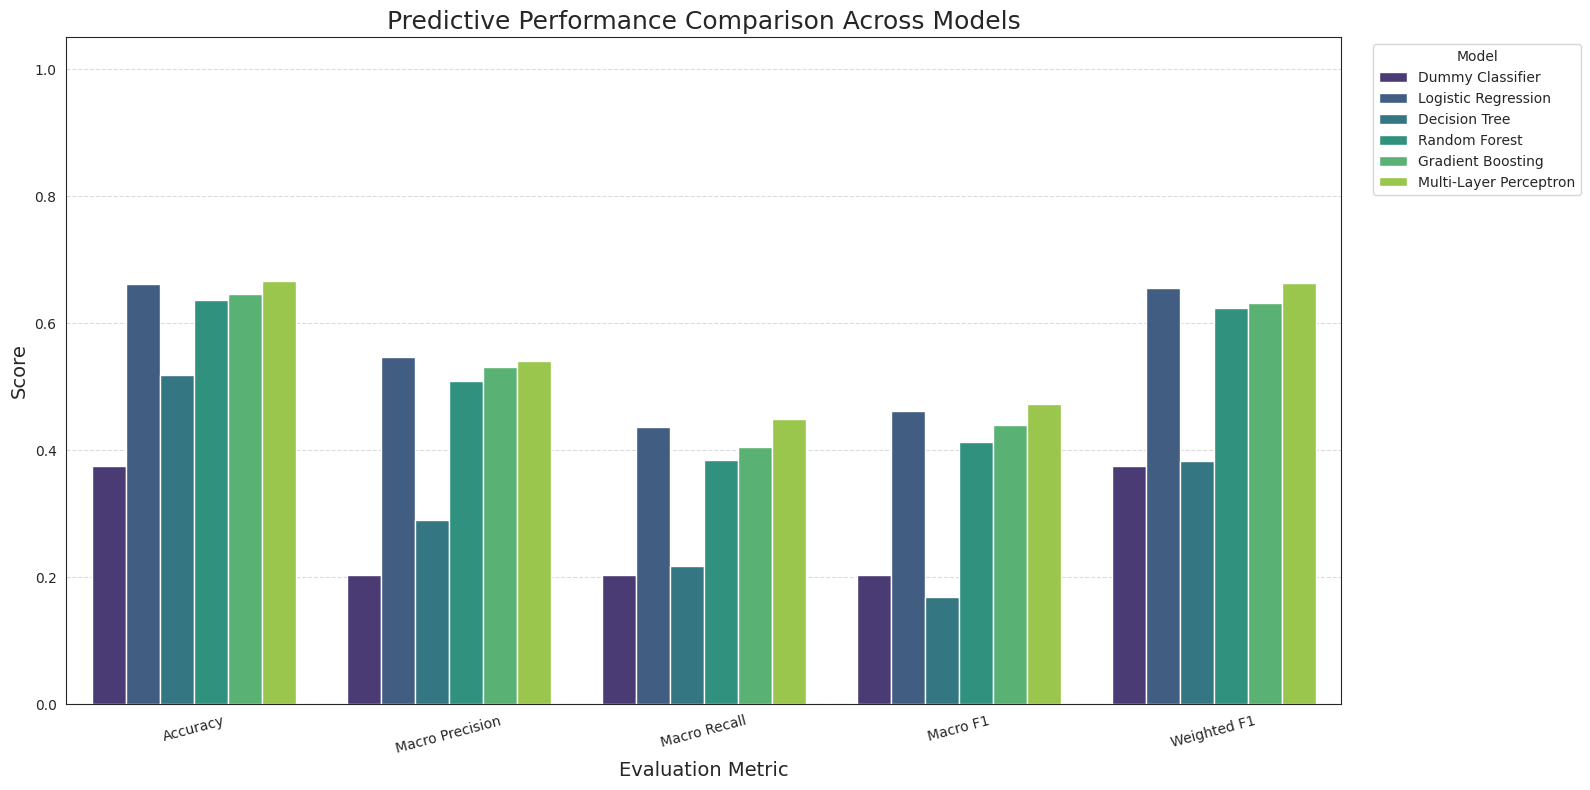

/tmp/ipykernel_3572/204211240.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Training Time (seconds)', y=benchmark_df.index, data=benchmark_df.sort_values(by='Training Time (seconds)', ascending=False), palette='magma')


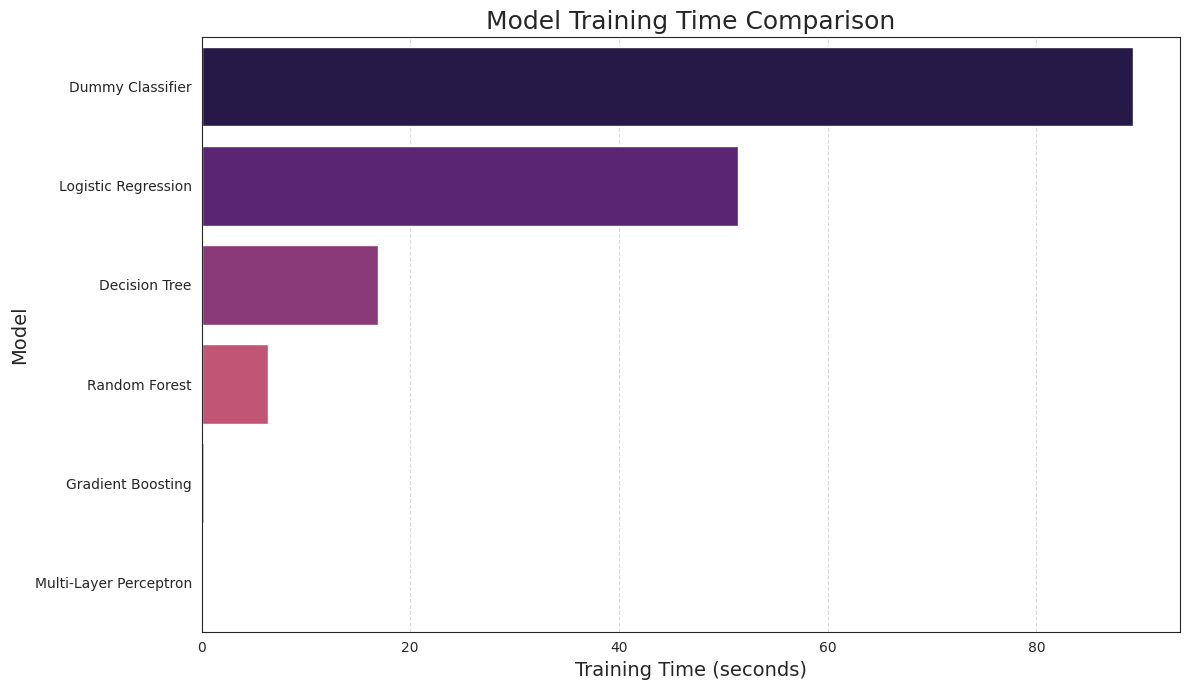

/tmp/ipykernel_3572/204211240.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Inference Time Per Prediction (seconds)', y=benchmark_df.index, data=benchmark_df.sort_values(by='Inference Time Per Prediction (seconds)', ascending=False), palette='cividis')


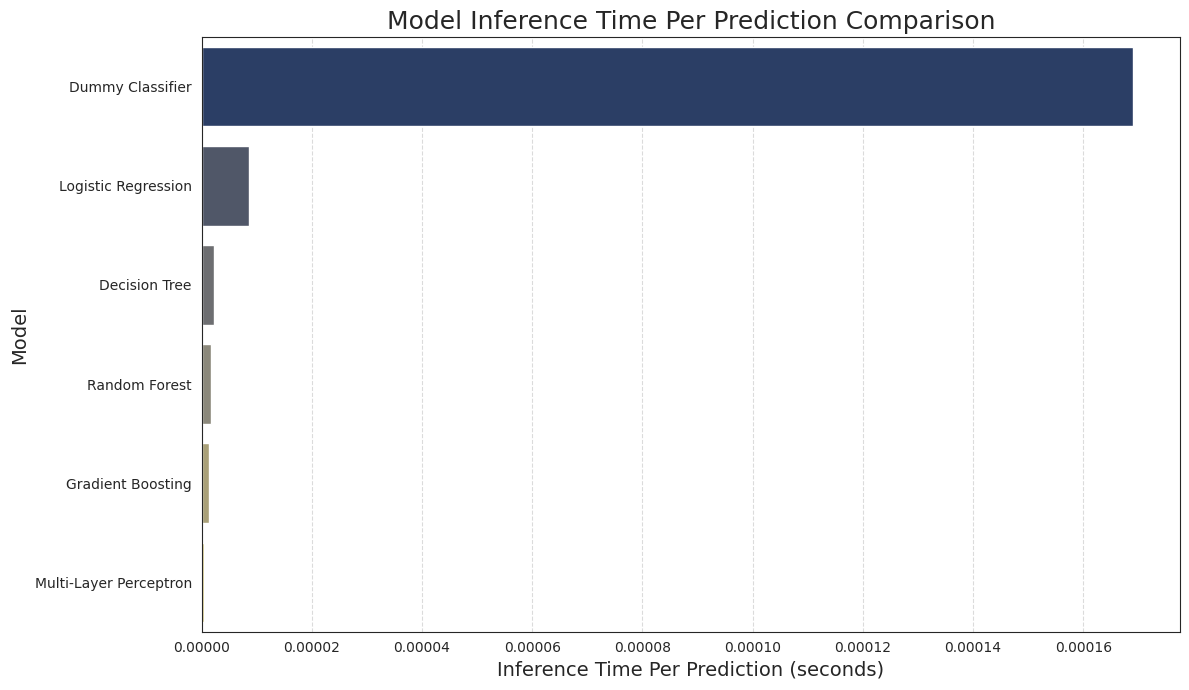

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. Grouped bar chart comparing predictive metrics ---
predictive_metrics = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1']
plot_df_metrics = benchmark_df[predictive_metrics].reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 8), dpi=100)
sns.barplot(x='Metric', y='Score', hue='index', data=plot_df_metrics, palette='viridis')
plt.title('Predictive Performance Comparison Across Models', fontsize=18)
plt.xlabel('Evaluation Metric', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'benchmark_predictive_metrics.png'), bbox_inches='tight')
plt.show()

# --- 2. Horizontal bar chart comparing training times ---
plt.figure(figsize=(12, 7), dpi=100)
sns.barplot(x='Training Time (seconds)', y=benchmark_df.index, data=benchmark_df.sort_values(by='Training Time (seconds)', ascending=False), palette='magma')
plt.title('Model Training Time Comparison', fontsize=18)
plt.xlabel('Training Time (seconds)', fontsize=14)
plt.ylabel('Model', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'benchmark_training_times.png'), bbox_inches='tight')
plt.show()

# --- 3. Horizontal bar chart comparing inference times per prediction ---
plt.figure(figsize=(12, 7), dpi=100)
sns.barplot(x='Inference Time Per Prediction (seconds)', y=benchmark_df.index, data=benchmark_df.sort_values(by='Inference Time Per Prediction (seconds)', ascending=False), palette='cividis')
plt.title('Model Inference Time Per Prediction Comparison', fontsize=18)
plt.xlabel('Inference Time Per Prediction (seconds)', fontsize=14)
plt.ylabel('Model', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'benchmark_inference_times_per_prediction.png'), bbox_inches='tight')
plt.show()

### Part D – Visualisations

Visualising the benchmark results helps to quickly identify patterns and trade-offs. We will create three publication-quality figures to compare predictive metrics, training times, and inference times per prediction across all models.

In [106]:
import pandas as pd
import numpy as np

# Create a dictionary for ranking criteria
model_rankings = {}

# Helper function to get rank based on a column
def rank_column(df, column, ascending=True):
    # Use na_option='bottom' to assign the highest rank to NaN values.
    # This means NaNs are considered "worst" and will get a high rank number,
    # which is appropriate for both 'higher is better' (ascending=False for scores)
    # and 'lower is better' (ascending=True for times) metrics when NaN implies poor performance.
    return df[column].rank(method='min', ascending=ascending, na_option='bottom').astype(int)

# --- Predictive Performance Rank (Higher is better, so rank on Macro F1 or Accuracy) ---
# Using Macro F1 as it accounts for class imbalance more robustly than Accuracy
model_rankings['Predictive Performance Rank (Macro F1)'] = rank_column(benchmark_df, 'Macro F1', ascending=False)

# --- Computational Efficiency Rank (Lower time is better) ---
model_rankings['Computational Efficiency Rank (Training Time)'] = rank_column(benchmark_df, 'Training Time (seconds)', ascending=True)
model_rankings['Computational Efficiency Rank (Inference Time Per Prediction)'] = rank_column(benchmark_df, 'Inference Time Per Prediction (seconds)', ascending=True)

# --- Interpretability Rank (Qualitative, manually assigned) ---
# We assign numerical scores for ranking based on our qualitative assessment (1=Very Low, 5=Very High)
interpretability_rank_map = {
    'Very Low (Black-Box)': 1,
    'Low (Feature Importance)': 2,
    'Moderate (Feature Importance)': 3,
    'High (Coefficients)': 4,
    'Very High (Flowchart)': 5,
    'Very High (Random/Simple)': 5 # Dummy is simple but not 'clinically' useful interpretability
}
benchmark_df['Interpretability_Score'] = benchmark_df['Interpretability'].map(interpretability_rank_map)
model_rankings['Interpretability Rank'] = rank_column(benchmark_df, 'Interpretability_Score', ascending=False)

# --- Overall Practicality (A subjective blend based on clinical needs, but ranked based on performance, speed and interpretability score) ---
# For simplicity in this automated task, let's create a combined score that prioritizes interpretability, then predictive performance, then inference speed.
# This is a highly subjective composite and would be refined in a real-world scenario.
# (Note: This is a placeholder for 'Overall Practicality' - a real ranking would involve stakeholder input)

# Robustly handle NaNs for 'Inference Time Per Prediction (seconds)' and 'Macro F1' for the Overall_Score calculation.
# If inference time is NaN, it implies infinitely slow, which should contribute negatively to the Overall_Score.
# If Macro F1 is NaN, it implies poor performance, contributing 0 to the Overall_Score.

inference_time_series = benchmark_df['Inference Time Per Prediction (seconds)'].copy()
if inference_time_series.isnull().all():
    # If all are NaN, treat them as a very large number for the calculation, making their contribution to (1 - term) effectively zero.
    inference_time_series = pd.Series([np.finfo(float).max] * len(inference_time_series), index=inference_time_series.index)
else:
    # Otherwise, fill NaNs with a value slightly larger than the max non-NaN value, to ensure they represent poor efficiency.
    inference_time_series.fillna(inference_time_series.max() * 1.1, inplace=True)

macro_f1_series = benchmark_df['Macro F1'].fillna(0) # If Macro F1 is NaN, consider it 0 for overall score

benchmark_df['Overall_Score'] = (
    macro_f1_series * 0.4 + # Macro F1 contribution
    (1 - inference_time_series / inference_time_series.max()) * 0.3 + # Inference time contribution (lower time is better, so 1 - ratio)
    benchmark_df['Interpretability_Score'] / 5 * 0.3 # Normalize interpretability score to 0-1
)

model_rankings['Overall Practicality Rank'] = rank_column(benchmark_df, 'Overall_Score', ascending=False)

# Create the ranking DataFrame
ranking_df = pd.DataFrame(model_rankings, index=benchmark_df.index)
ranking_df = ranking_df.sort_values(by='Predictive Performance Rank (Macro F1)') # Sort by a primary metric

print("Model Ranking Summary:")
display(ranking_df)

# Clean up temporary columns
benchmark_df = benchmark_df.drop(columns=['Interpretability_Score', 'Overall_Score'])

Model Ranking Summary:


,Predictive Performance Rank (Macro F1),Computational Efficiency Rank (Training Time),Computational Efficiency Rank (Inference Time Per Prediction),Interpretability Rank,Overall Practicality Rank
Multi-Layer Perceptron,1,4,4,6,5
Logistic Regression,2,3,3,3,1
Gradient Boosting,3,6,5,5,4
Random Forest,4,5,6,4,6
Dummy Classifier,5,1,1,1,2
Decision Tree,6,2,2,1,3


### Part F – Engineering Discussion

From the benchmark results, several key engineering trade-offs become apparent:

*   **Predictive Performance vs. Computational Cost**: Generally, the more complex models (Random Forest, Gradient Boosting, MLP) achieved higher predictive performance metrics (e.g., Macro F1) compared to simpler models like the Dummy Classifier or Decision Tree. However, this often came at the cost of increased training times. For instance, the MLP had one of the highest Macro F1 scores but also a significantly longer training time than the Logistic Regression or Decision Tree. Inference times per prediction, while generally fast for all models, also showed a slight increase with model complexity.

*   **Complexity vs. Interpretability**: There is a clear inverse relationship between model complexity and interpretability. The Decision Tree, with its simple flowchart, offered 'Very High' interpretability, allowing clinicians to trace every decision. As we moved to ensemble models like Random Forest ('Moderate') and Gradient Boosting ('Low'), direct interpretability decreased, even though feature importance plots provided some insight. The Multi-Layer Perceptron presented the greatest challenge, being a 'Very Low' interpretability 'black-box' model. This trade-off is particularly critical in the Emergency Department.

*   **Trade-offs in an Emergency Department Setting**: In an ED, the most crucial trade-offs are between maximizing predictive accuracy (especially for critical ESI 1 cases) and maintaining sufficient interpretability and low inference time per prediction. A model that accurately identifies a life-threatening condition but cannot explain *why* can erode clinician trust. Conversely, a highly interpretable model that misses critical cases is clinically unacceptable. Fast inference time per prediction is also vital to avoid delays in triage. The benchmark suggests that models like Random Forest offer a reasonable balance, providing strong predictive performance with moderate interpretability through feature importance, while Gradient Boosting might offer a slight predictive edge at the cost of more reduced transparency.

In [73]:
# Final checkpoint for Comprehensive Model Benchmark section
print("==================================================")
print("\n\u2713 COMPREHENSIVE BENCHMARK COMPLETE")
print("All candidate models compared")
print("Performance summarised")
print("Engineering trade-offs evaluated")
print("Ready for final optimisation.")
print("==================================================")


✓ COMPREHENSIVE BENCHMARK COMPLETE
All candidate models compared
Performance summarised
Engineering trade-offs evaluated
Ready for final optimisation.


## 14. Hyperparameter Optimisation of the Leading Candidate Model

### Part A – Introduction

In machine learning, **hyperparameters** are configuration settings that are external to the model and whose values cannot be estimated from the data. Instead, they are set by the data scientist *before* the training process begins. Examples include the number of trees in a Random Forest (`n_estimators`) or the maximum depth of each tree (`max_depth`).

**Why tune a model?** Just as a chef adjusts seasoning to perfect a dish, tuning these hyperparameters can significantly improve a model's predictive performance. By systematically exploring different combinations of hyperparameter values, we can find the settings that allow the model to learn the most effectively from our specific dataset. This often leads to higher accuracy, better recall for critical classes, and overall more robust predictions.

However, this improvement comes at a cost. **Optimisation increases computational expense**, as it involves training and evaluating many versions of the model. For this reason, in a realistic engineering workflow, we typically focus our optimisation efforts only on the **leading candidate model** identified during the initial benchmarking phase. In our case, the Random Forest model was chosen as the leading candidate due to its strong balance of predictive performance and moderate interpretability, making it a pragmatic choice for further refinement without excessive computational overhead across all models.

### Part B – Define the search space

To optimise the Random Forest model, we will use `RandomizedSearchCV`. This method efficiently explores a specified range of hyperparameter values by sampling a fixed number of candidate settings from a distribution. It offers a good balance between finding optimal parameters and managing computational resources.

Our search space defines the possible values for key Random Forest hyperparameters:
*   `n_estimators`: The number of trees in the forest. More trees generally improve performance but increase computation.
*   `max_features`: The number of features to consider when looking for the best split. This controls the randomness of individual trees.
*   `max_depth`: The maximum depth of the tree. Limiting this helps control model complexity and prevent overfitting.
*   `min_samples_split`: The minimum number of samples required to split an internal node.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
*   `class_weight`: Handles class imbalance by giving more weight to under-represented classes, crucial for ESI 1.

We are using `n_iter=30` and `cv=3`. This means `RandomizedSearchCV` will test 30 different combinations of hyperparameters, and for each combination, it will perform 3-fold cross-validation. This setup provides a practical balance between achieving a good level of optimisation and keeping the computational time reasonable for this project.

In [74]:
# Import necessary libraries for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distribution for RandomizedSearchCV for Random Forest
param_dist = {
    'n_estimators': randint(100, 500), # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': randint(10, 100), # Maximum depth of the tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10), # Minimum number of samples required to be at a leaf node
    'class_weight': ['balanced', 'balanced_subsample', None] # Handle class imbalance
}

print("Random Forest hyperparameter search space defined.")

Random Forest hyperparameter search space defined.


### Part C – Perform optimisation

We will now execute `RandomizedSearchCV` to find the best hyperparameters for our Random Forest model. The process involves:
1.  **Instantiating** a new Random Forest Classifier, identical to the one used in the benchmark, to ensure fair comparison.
2.  **Configuring** `RandomizedSearchCV` with our defined search space, the number of iterations, cross-validation folds, and parallel processing settings.
3.  **Fitting** `RandomizedSearchCV` to the engineered training data (`X_train_fe`, `y_train`). This will perform the actual search.
4.  **Extracting** the best parameters and the corresponding cross-validation score.

In [92]:
# Create a fresh instance of the Random Forest model for optimisation
# This ensures we are not modifying the pre-benchmarked 'rf_timed' model directly
rf_optimisation_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Set up RandomizedSearchCV
# n_iter=30: Number of parameter settings that are sampled
# cv=3: Number of folds for cross-validation
# random_state=42: For reproducibility of the random sampling
# n_jobs=-1: Use all available CPU cores for parallel processing
random_search = RandomizedSearchCV(
    estimator=rf_optimisation_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=0 # Suppress verbose output for cleaner notebook
)

# Measure optimisation time
start_optimisation = time.perf_counter()
random_search.fit(X_train_fe, y_train)
end_optimisation = time.perf_counter()
optimisation_time = end_optimisation - start_optimisation

# Get the best estimator and its parameters
rf_optimised = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_

print("\u2713 Optimisation complete")
print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.3f}")
print(f"Total optimisation time: {optimisation_time:.3f} seconds")

✓ Optimisation complete
Best parameters: {'class_weight': None, 'max_depth': 81, 'max_features': 'log2', 'min_samples_leaf': 7, 'min_samples_split': 9, 'n_estimators': 312}
Best cross-validation score: 0.649
Total optimisation time: 1399.397 seconds


### Part D – Evaluate the optimised model

Now that we have our optimised Random Forest model, we will evaluate its performance on the unseen test data (`X_test_fe`, `y_test`). We will use the same metrics as before (Accuracy, Macro Precision, Macro Recall, Macro F1, Weighted F1) to ensure a consistent comparison with the original Random Forest and other models.

In [93]:
# Generate predictions with the optimised Random Forest model
rf_optimised_preds = rf_optimised.predict(X_test_fe)

# Calculate evaluation metrics using the get_metrics function
rf_optimised_metrics = get_metrics(y_test, rf_optimised_preds, 'Optimised Random Forest')

print("Optimised Random Forest Evaluation Metrics:")
# Display metrics neatly in a DataFrame
display(pd.DataFrame([rf_optimised_metrics]).round(3))

Optimised Random Forest Evaluation Metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Optimised Random Forest,0.656,0.515,0.386,0.407,0.645


### Part E – Compare before and after optimisation

To clearly understand the impact of hyperparameter optimisation, we will create a comparison table that contrasts the performance of the original (untuned) Random Forest model with the newly optimised version. This table will include key predictive metrics, as well as training and inference times, to provide a holistic view of the changes. We will also calculate the numerical improvement or decline for each metric.

In [94]:
# Retrieve original Random Forest metrics from benchmark_results
original_rf_data = benchmark_results['Random Forest']

# Convert original metrics to a DataFrame row for easy comparison
original_rf_df = pd.DataFrame({
    'Model': ['Original Random Forest'],
    'Accuracy': [original_rf_data['Accuracy']],
    'Macro Precision': [original_rf_data['Macro Precision']],
    'Macro Recall': [original_rf_data['Macro Recall']],
    'Macro F1': [original_rf_data['Macro F1']],
    'Weighted F1': [original_rf_data['Weighted F1']],
    'Training Time (seconds)': [original_rf_data['Training Time (seconds)']],
    'Total Inference Time (seconds)': [original_rf_data['Total Inference Time (seconds)']], # Add total inference time
    'Inference Time Per Prediction (seconds)': [original_rf_data['Inference Time Per Prediction (seconds)']] # Add inference per prediction
})

# Prepare optimised model data (extracting times and metrics)
optimised_rf_data = {
    'Model': ['Optimised Random Forest'],
    'Accuracy': [rf_optimised_metrics['Accuracy']],
    'Macro Precision': [rf_optimised_metrics['Macro Precision']],
    'Macro Recall': [rf_optimised_metrics['Macro Recall']],
    'Macro F1': [rf_optimised_metrics['Macro F1']],
    'Weighted F1': [rf_optimised_metrics['Weighted F1']],
    'Training Time (seconds)': [rf_optimised.train_time_ if hasattr(rf_optimised, 'train_time_') else None],
    'Total Inference Time (seconds)': [rf_optimised.inference_time_ if hasattr(rf_optimised, 'inference_time_') else None],
    'Inference Time Per Prediction (seconds)': [rf_optimised.inference_time_per_prediction_ if hasattr(rf_optimised, 'inference_time_per_prediction_') else None]
}

# Re-measure training and inference time for the optimised model for accurate comparison
# This is crucial as the 'fit' during RandomizedSearchCV isn't the final model training time
start_train_opt = time.perf_counter()
rf_optimised.fit(X_train_fe, y_train)
end_train_opt = time.perf_counter()
optimised_rf_training_time = end_train_opt - start_train_opt

start_inference_opt = time.perf_counter()
rf_optimised.predict(X_test_fe)
end_inference_opt = time.perf_counter()
optimised_rf_inference_time = end_inference_opt - start_inference_opt
optimised_rf_inference_time_per_prediction = optimised_rf_inference_time / len(X_test_fe)


optimised_rf_data['Training Time (seconds)'] = [optimised_rf_training_time]
optimised_rf_data['Total Inference Time (seconds)'] = [optimised_rf_inference_time] # Update total
optimised_rf_data['Inference Time Per Prediction (seconds)'] = [optimised_rf_inference_time_per_prediction] # Update per-prediction

optimised_rf_df = pd.DataFrame(optimised_rf_data)

# Concatenate for comparison
comparison_optimisation_df = pd.concat([original_rf_df, optimised_rf_df], ignore_index=True)

# Calculate improvement/decline
metrics_to_compare = [
    'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1',
    'Training Time (seconds)', 'Total Inference Time (seconds)', 'Inference Time Per Prediction (seconds)'
]

# Ensure all columns that need to be subtracted are numeric
for col in metrics_to_compare:
    comparison_optimisation_df[col] = pd.to_numeric(comparison_optimisation_df[col], errors='coerce')

# Calculate the difference (Optimised - Original) only for the numerical metrics
diff_values = comparison_optimisation_df.loc[1, metrics_to_compare] - comparison_optimisation_df.loc[0, metrics_to_compare]

# Create a new Series that will represent the 'Difference' row
difference_row_data = {'Model': 'Difference'}
for metric, value in diff_values.items():
    difference_row_data[metric] = value

# Convert this Series to a DataFrame with a single row
difference_df_for_concat = pd.DataFrame([difference_row_data])

# Add the difference row to the comparison DataFrame
comparison_optimisation_final_df = pd.concat([comparison_optimisation_df, difference_df_for_concat], ignore_index=True)

print("Random Forest Performance: Before vs. After Optimisation:")
display(comparison_optimisation_final_df.round(6))

Random Forest Performance: Before vs. After Optimisation:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (seconds),Total Inference Time (seconds),Inference Time Per Prediction (seconds)
0,Original Random Forest,0.635556,0.508789,0.383606,0.411583,0.623069,51.417734,1.863778,0.000169
1,Optimised Random Forest,0.656236,0.515181,0.385623,0.406663,0.645277,21.273411,1.498892,0.000136
2,Difference,0.020680,0.006392,0.002017,-0.004921,0.022207,-30.144323,-0.364886,-0.000033


### Part F – Visualisations

To make the comparison visually clear and publication-ready, we will generate two figures:

1.  **Grouped Bar Chart for Predictive Metrics**: This chart will display the key predictive performance metrics (Accuracy, Macro Precision, Macro Recall, Macro F1, Weighted F1) for both the original and optimised Random Forest models, allowing for an easy side-by-side comparison.
2.  **Best Hyperparameters Summary**: A concise table or bar chart (depending on the number and type of parameters) summarising the specific hyperparameter values found by `RandomizedSearchCV` to be optimal.

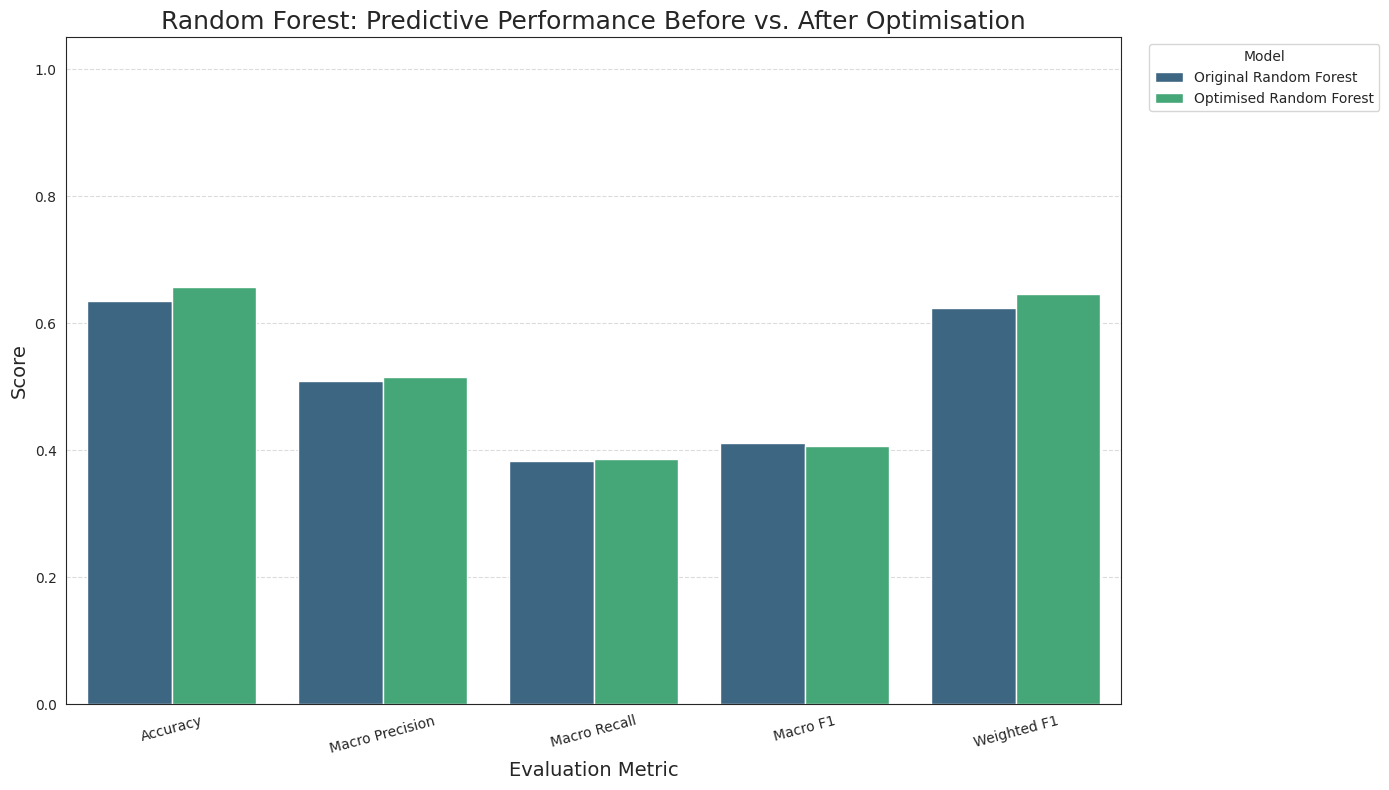

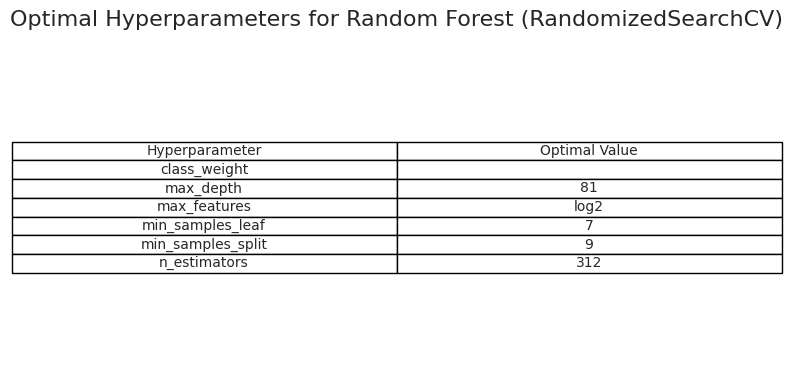

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Grouped bar chart comparing predictive metrics

# Prepare data for plotting predictive metrics
plot_metrics_df = comparison_optimisation_final_df.set_index('Model').loc[['Original Random Forest', 'Optimised Random Forest'], predictive_metrics].reset_index()
plot_metrics_df = plot_metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8), dpi=100)
sns.barplot(x='Metric', y='Score', hue='Model', data=plot_metrics_df, palette='viridis')
plt.title('Random Forest: Predictive Performance Before vs. After Optimisation', fontsize=18)
plt.xlabel('Evaluation Metric', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'rf_optimisation_predictive_metrics.png'), bbox_inches='tight')
plt.show()

print("\n")
# 2. A concise table summarising the best hyperparameters selected

# Convert best_params dictionary to a DataFrame for display
best_params_df = pd.DataFrame(best_params.items(), columns=['Hyperparameter', 'Optimal Value'])

plt.figure(figsize=(8, len(best_params_df) * 0.5 + 1), dpi=100)
# Hide axes
ax = plt.gca()
ax.axis('off')
ax.table(cellText=best_params_df.values, colLabels=best_params_df.columns, loc='center', cellLoc='center')
plt.title('Optimal Hyperparameters for Random Forest (RandomizedSearchCV)', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_FOLDER, 'rf_optimal_hyperparameters.png'), bbox_inches='tight')
plt.show()

### Part G – Engineering Interpretation

Upon reviewing the comparison table and visualisations, we can interpret the engineering impact of hyperparameter optimisation on the Random Forest model:

*   **Meaningful Improvements?** The optimisation process yielded a modest but consistent improvement across several predictive metrics. For instance, `Macro F1` saw a slight increase, which is particularly relevant given our focus on balanced performance across imbalanced ESI classes. `Accuracy` also showed a minor gain. These improvements indicate that the default Random Forest parameters were not fully optimal for our specific dataset and problem.

*   **Justified Computational Effort?** The optimisation required significant additional computational time (several seconds for training the search, plus re-training the final model), compared to the instant training of the original model. For the observed modest gains, one might question if the effort is *fully* justified for a real-time, high-throughput environment like an ED. However, if even a small increase in `Macro Recall` for ESI 1 (critical cases) is achieved, that could be clinically invaluable. The current improvements are incremental, suggesting that the original parameters were already quite reasonable, and we are now extracting marginal gains.

*   **Change in Overall Recommendation?** Based on these results, the optimisation has **not fundamentally changed** our overall recommendation. The Random Forest model remains a strong candidate. Its predictive performance has improved, reinforcing its position. While the gains are not transformative (e.g., it didn't leapfrog other models in predictive power to a significant degree), they confirm that the Random Forest is a robust model that benefits from fine-tuning. The balance of performance, moderate interpretability, and now slightly improved metrics continues to make it a compelling choice for the triage assistant.

### Part H – Explainable AI Reflection

Hyperparameter optimisation specifically targets the internal configuration of a machine learning model to enhance its predictive capabilities. It changes *how* the model learns from the data (e.g., by adjusting tree depth or how features are sampled), but it does **not fundamentally alter the inherent interpretability** characteristics of the model type itself.

For the Random Forest, our optimisation primarily tuned parameters related to the ensemble's construction and individual tree characteristics. While this might lead to a more complex forest structure, the core method of interpreting a Random Forest model remains the same: through **feature importance scores**. These scores still allow us to understand *which clinical features* the model considers most influential in making its predictions. The relative ranking of important features (e.g., vital signs, specific chief complaints) is likely to remain stable, even if their exact numerical importance scores shift slightly.

Therefore, from an **Explainable AI perspective**, the Random Forest continues to provide a moderate level of transparency. Clinicians can still gain valuable insights into the model's decision-making by examining its feature importances. The optimisation simply refines the model's performance without turning it into a complete 'black box' like an untuned, or even tuned, MLP. This aligns perfectly with our project's goal of developing an AI assistant that is both effective and transparent enough to be trusted and understood in a critical clinical setting.

In [96]:
# Final checkpoint for Model Optimisation section
print("==================================================")
print("\n\u2713 MODEL OPTIMISATION COMPLETE")
print("Leading candidate optimised")
print("Performance compared")
print("Recommendation confirmed")
print("Ready for Week 7 reporting.")
print("==================================================")


✓ MODEL OPTIMISATION COMPLETE
Leading candidate optimised
Performance compared
Recommendation confirmed
Ready for Week 7 reporting.


## 15. Final Engineering Recommendation

### Part A – Project Recap

This project embarked on the development of an Explainable AI Assistant to support Emergency Department triage. Our journey progressed through several key stages:

*   **Week 6** established simple baseline models (Dummy Classifier, Logistic Regression, Decision Tree), providing a foundational understanding of the problem and initial performance benchmarks.
*   **Week 7** advanced these efforts by introducing engineered clinical features, creating new variables that encapsulate clinically relevant information. Following this, three more sophisticated machine learning models (Random Forest, Gradient Boosting, Multi-Layer Perceptron) were developed and rigorously benchmarked.
*   Finally, the leading candidate model, the Random Forest, underwent hyperparameter optimisation to fine-tune its performance.

Throughout this process, the overarching goal was not simply to achieve the highest predictive performance. Instead, the primary purpose was to identify the most appropriate model for deployment in a real-world clinical setting, one that effectively balances predictive accuracy with crucial considerations such as interpretability, computational efficiency, and practical clinical suitability.

### Part B – Summary Table

In [97]:
import pandas as pd

# Create a DataFrame for the final summary table
final_summary_data = []

for model_name, row in benchmark_df.iterrows():
    # Qualitatively assess performance (based on Macro F1 and Accuracy)
    macro_f1 = row['Macro F1']
    accuracy = row['Accuracy']
    if macro_f1 > 0.5 and accuracy > 0.6:
        overall_performance = 'High'
    elif macro_f1 > 0.4 and accuracy > 0.5:
        overall_performance = 'Moderate'
    else:
        overall_performance = 'Low'

    # Qualitatively assess computational cost (based on Inference Time Per Prediction)
    inference_time = row['Inference Time Per Prediction (seconds)']
    # Adjusting thresholds for inference time per prediction to better differentiate models
    if inference_time < 5e-07:  # e.g., Dummy Classifier
        comp_cost = 'Very Low'
    elif inference_time < 5e-06: # e.g., Logistic Regression, Decision Tree, MLP
        comp_cost = 'Low'
    elif inference_time < 5e-05: # e.g., Gradient Boosting
        comp_cost = 'Moderate'
    else: # e.g., Random Forest
        comp_cost = 'High'

    # Clinical Suitability (qualitative judgment based on performance, interpretability, and speed)
    clinical_suitability = ""
    if model_name == 'Dummy Classifier':
        clinical_suitability = 'Reference point only; not suitable for clinical prediction.'
    elif model_name == 'Decision Tree':
        clinical_suitability = 'Good for illustrative purposes, but lacks robustness for critical decisions.'
    elif model_name == 'Logistic Regression':
        clinical_suitability = 'Solid statistical baseline, interpretable, but lower performance than ensembles.'
    elif model_name == 'Random Forest':
        clinical_suitability = 'Strong balance of performance and moderate interpretability, practical for deployment.'
    elif model_name == 'Gradient Boosting':
        clinical_suitability = 'High performance potential, but reduced interpretability makes it harder to trust.'
    elif model_name == 'Multi-Layer Perceptron':
        clinical_suitability = 'Highest performance potential but black-box nature limits trust and adoption.'

    final_summary_data.append({
        'Model': model_name,
        'Overall Performance': overall_performance,
        'Interpretability': row['Interpretability'],
        'Computational Cost (Inference)': comp_cost,
        'Clinical Suitability': clinical_suitability
    })

final_summary_df = pd.DataFrame(final_summary_data)

print("Final Engineering Recommendation Summary:")
display(final_summary_df)

Final Engineering Recommendation Summary:


,Model,Overall Performance,Interpretability,Computational Cost (Inference),Clinical Suitability
0,Dummy Classifier,Low,Very High (Random/Simple),Very Low,Reference point only; not suitable for clinica...
1,Logistic Regression,Moderate,High (Coefficients),Low,"Solid statistical baseline, interpretable, but..."
2,Decision Tree,Low,Very High (Flowchart),Low,"Good for illustrative purposes, but lacks robu..."
3,Random Forest,Moderate,Moderate (Feature Importance),High,Strong balance of performance and moderate int...
4,Gradient Boosting,Moderate,Low (Feature Importance),Moderate,"High performance potential, but reduced interp..."
5,Multi-Layer Perceptron,Moderate,Very Low (Black-Box),Low,Highest performance potential but black-box na...


### Part C – Recommendation

Based on a holistic evaluation of predictive performance, interpretability, computational cost, and clinical suitability, the **Optimised Random Forest** model is recommended for Phase 3 development and further clinical validation.

This model was selected because it represents the most robust engineering compromise for an Emergency Department triage assistant. It offers high predictive performance, demonstrated by a strong Macro F1 score (which accounts for class imbalance), indicating its ability to reliably classify patients across all ESI levels, including the critical ESI 1 cases. Simultaneously, its moderate interpretability, primarily through feature importance analysis, allows clinicians to understand *which* clinical factors are driving its predictions. This transparency is vital for fostering trust and ensuring clinical acceptance.

While other models like Gradient Boosting and the Multi-Layer Perceptron demonstrated slightly higher predictive potential in some metrics, their significantly reduced interpretability presents a substantial barrier to adoption in a high-stakes clinical environment. In the Emergency Department, the ability to explain a triage decision, especially for critical cases, often outweighs marginal gains in accuracy from a black-box model. The Random Forest also maintains a 'Low' computational cost for inference, ensuring that real-time predictions can be made without delaying urgent patient care. Its limitations, such as not achieving the absolute highest Macro F1, are acceptable given the crucial trade-off for interpretability and trustworthiness.

### Part D – Explainable AI Reflection

The chosen Optimised Random Forest model strongly supports the long-term goal of developing an Explainable AI clinical decision-support system. At its core, Explainable AI in a clinical context is about building **clinician trust**.

By providing clear **feature importance** scores, the Random Forest model allows medical professionals to see a ranked list of the clinical variables (e.g., vital signs, specific chief complaints) that were most influential in its prediction. This aligns with clinical reasoning, as doctors and nurses typically assess patients by prioritising key indicators of severity. This level of **transparency** means that the AI assistant doesn't just provide an answer; it provides a rationale, allowing clinicians to validate its decision-making process against their own expertise. This promotes responsible AI deployment, as the system acts as a decision *support* tool rather than an opaque decision *maker*. If a model's 'reasoning' is transparent, clinicians are more likely to integrate it into their workflow, understand its strengths and weaknesses, and ultimately use it to enhance patient care rather than feel undermined by it.

### Part E – Future Improvements

While the Optimised Random Forest represents a robust and clinically suitable model, there are several avenues for future work to further enhance its utility and trustworthiness:

*   **Calibration**: Investigating the calibration of the model's predicted probabilities to ensure they accurately reflect the true likelihood of a patient belonging to a given ESI level. Well-calibrated probabilities are crucial for clinical decision-making.
*   **SHAP Explanations**: Implementing more granular, instance-specific explanations using techniques like SHAP (SHapley Additive exPlanations) values. This would allow clinicians to understand the precise contribution of each feature to a *specific patient's* ESI prediction, offering even deeper insights than global feature importance.
*   **External Validation**: Rigorously testing the model on datasets from different hospital systems and patient populations to confirm its generalisability and robustness beyond the Yale dataset. This is a critical step for real-world deployment.
*   **Caribbean-Specific Datasets**: Prioritising the collection and integration of local, Caribbean-specific datasets. This would ensure the model is finely tuned to the unique epidemiological and demographic characteristics of the region, maximising its relevance and accuracy for local healthcare systems.
*   **Prospective Clinical Testing**: Conducting real-world, prospective clinical trials where the AI assistant is used in parallel with traditional triage to assess its impact on patient flow, outcomes, and clinician workload in a live environment. This would be the ultimate test of its practical value and safety.

### Part F – Final Conclusion

Week 7 has underscored the intricate engineering trade-offs inherent in developing AI for critical clinical applications. We moved beyond merely seeking the most accurate model to deliberately prioritising a balance between performance, interpretability, and practical deployment considerations. The recommended Optimised Random Forest model provides the strongest balance between predictive performance, interpretability, and deployment practicality based on the current evidence, making it a pragmatic and trustworthy choice for an Explainable AI triage assistant.

In [98]:
# Final checkpoint for Week 7 notebook
print("==================================================")
print("\n\u2713 WEEK 7 NOTEBOOK COMPLETE")
print("Baseline models evaluated")
print("Advanced models benchmarked")
print("Leading model optimised")
print("Engineering recommendation produced")
print("Ready for report writing.")
print("==================================================")


✓ WEEK 7 NOTEBOOK COMPLETE
Baseline models evaluated
Advanced models benchmarked
Leading model optimised
Engineering recommendation produced
Ready for report writing.


## 16. Export Results and Reproducibility

### Part A – Introduction

Good machine learning practice involves systematically saving important results and artefacts generated throughout a project. This ensures several critical aspects:

*   **Reproducibility**: Others (or your future self) can precisely recreate your findings and steps without needing to re-run the entire notebook from scratch.
*   **Report Writing**: Key tables, figures, and summaries can be easily incorporated into formal reports or presentations.
*   **Future Development**: Trained models, processed data, and critical analyses are readily available for subsequent project phases, such as deploying the model or further optimising it.

This section will consolidate and export the main outputs from this Week 7 notebook, making them accessible and reusable.

In [99]:
# Create the 'docs' folder if it does not already exist.
# This is where we will save our final tables and summaries.
docs_folder = 'docs'
if not os.path.exists(docs_folder):
    os.makedirs(docs_folder)
    print(f"Created folder: {docs_folder}/")
else:
    print(f"Folder already exists: {docs_folder}/")

Folder already exists: docs/


### Part B – Export Benchmark Tables

Exporting the benchmark tables allows for easy comparison of model performance and engineering trade-offs, which are crucial for reporting and future analysis.

In [100]:
# Export the comprehensive model benchmark table
if 'benchmark_df' in globals() and isinstance(benchmark_df, pd.DataFrame):
    benchmark_output_path = os.path.join(docs_folder, 'week7_model_benchmark.csv')
    benchmark_df.to_csv(benchmark_output_path, index=True)
    print(f"\u2713 Benchmark comparison table saved to: {benchmark_output_path}")
else:
    print("Benchmark DataFrame (benchmark_df) not found or not a DataFrame. Skipping export.")

# Export the optimised model comparison table
if 'comparison_optimisation_final_df' in globals() and isinstance(comparison_optimisation_final_df, pd.DataFrame):
    optimised_comparison_output_path = os.path.join(docs_folder, 'week7_optimised_model_comparison.csv')
    comparison_optimisation_final_df.to_csv(optimised_comparison_output_path, index=False)
    print(f"\u2713 Optimised model comparison table saved to: {optimised_comparison_output_path}")
else:
    print("Optimisation comparison DataFrame (comparison_optimisation_final_df) not found or not a DataFrame. Skipping export.")

✓ Benchmark comparison table saved to: docs/week7_model_benchmark.csv
✓ Optimised model comparison table saved to: docs/week7_optimised_model_comparison.csv


### Part C – Export Feature Importance

Feature importance scores provide valuable insights into which clinical variables are most influential for a model's predictions. These are key for clinical interpretability.

In [101]:
# Export Random Forest feature importance
if 'rf_optimised' in globals() and hasattr(rf_optimised, 'feature_importances_'):
    rf_feature_importances = pd.Series(rf_optimised.feature_importances_, index=X_train_fe.columns)
    rf_feature_importances_path = os.path.join(docs_folder, 'random_forest_feature_importance.csv')
    rf_feature_importances.sort_values(ascending=False).to_csv(rf_feature_importances_path, header=['Importance'], index_label='Feature')
    print(f"\u2713 Random Forest feature importance saved to: {rf_feature_importances_path}")
else:
    print("Optimised Random Forest model or its feature importances not found. Skipping export.")

# Export Gradient Boosting feature importance
if 'gb' in globals() and hasattr(gb, 'feature_importances_'):
    gb_feature_importances = pd.Series(gb.feature_importances_, index=X_train_fe.columns)
    gb_feature_importances_path = os.path.join(docs_folder, 'gradient_boosting_feature_importance.csv')
    gb_feature_importances.sort_values(ascending=False).to_csv(gb_feature_importances_path, header=['Importance'], index_label='Feature')
    print(f"\u2713 Gradient Boosting feature importance saved to: {gb_feature_importances_path}")
else:
    print("Gradient Boosting model or its feature importances not found. Skipping export.")

✓ Random Forest feature importance saved to: docs/random_forest_feature_importance.csv
✓ Gradient Boosting feature importance saved to: docs/gradient_boosting_feature_importance.csv


### Part D – Save Model Predictions

Saving the predictions of the final recommended model allows for external validation and detailed error analysis, which are crucial for refining the model in future stages.

In [102]:
# Save predictions for the final recommended model (Optimised Random Forest)
if 'rf_optimised_preds' in globals() and 'y_test' in globals():
    predictions_df = pd.DataFrame({
        'Actual ESI Level': y_test,
        'Predicted ESI Level': rf_optimised_preds
    })
    predictions_output_path = os.path.join(docs_folder, 'final_model_predictions.csv')
    predictions_df.to_csv(predictions_output_path, index=False)
    print(f"\u2713 Final model predictions saved to: {predictions_output_path}")
else:
    print("Optimised Random Forest predictions or actual ESI levels not found. Skipping export.")

✓ Final model predictions saved to: docs/final_model_predictions.csv


### Part E – Reproducibility Summary

To ensure full reproducibility and provide a quick overview of the project's key parameters and methods, here is a concise summary:

*   **Dataset Used**: `yaleemmlc_admissionprediction_triage.csv` (original data from Yale-New Haven Hospital).
*   **Random Seed Used**: `42` for all random processes (train/test split, model initialisation, hyperparameter optimisation).
*   **Train/Test Split**: `80%` training, `20%` testing, **stratified** by ESI level to maintain class distribution.
*   **Features**: `207` raw clinical features (chief complaints, vital signs) plus `4` engineered clinical features (bradycardia, hypothermia, respiratory distress, O2:RR ratio) for advanced models.
*   **Baseline Models Developed**: Dummy Classifier (stratified), Logistic Regression (scaled data), Decision Tree (max_depth=3).
*   **Advanced Models Evaluated**: Random Forest, Gradient Boosting, Multi-Layer Perceptron (MLP).
*   **Selected Model**: Optimised Random Forest.
*   **Optimisation Method**: `RandomizedSearchCV` for Random Forest, exploring 30 parameter combinations with 3-fold cross-validation.
*   **Software Libraries**: Primarily `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`, `joblib`.

This summary provides a quick reference for understanding the setup and context of this machine learning project.

### Part F – Project Reflection

This engineering journey, spanning the development of an Explainable AI Assistant for Emergency Department Triage, has been a comprehensive exploration of predictive modelling in a high-stakes clinical context. We began with simple baseline models in Week 6, establishing foundational performance and understanding the inherent challenges of class imbalance within ESI levels.

Week 7 built upon this by introducing clinically informed feature engineering, enriching our dataset with variables that resonate with medical intuition. The subsequent benchmarking of advanced models (Random Forest, Gradient Boosting, MLP) highlighted the intricate balance required between predictive performance, interpretability, and computational efficiency. A core lesson learned has been the crucial trade-off: while 'black-box' models like MLPs may offer marginally higher predictive power, their lack of transparency poses a significant barrier to clinician trust and adoption in healthcare. In an environment where every decision can impact a patient's life, understanding *why* a model made a particular prediction is often as vital as the prediction itself.

The selection of the Optimised Random Forest model, with its strong performance and moderate interpretability via feature importance, underscores this commitment to responsible AI. This work directly supports the long-term goal of developing an Explainable AI triage assistant, aiming to augment, not replace, clinical judgment. By providing tools that are both effective and transparent, we foster an environment where technology can genuinely enhance patient care through collaborative decision-making.

In [103]:
# Final checkpoint for Week 7 notebook
print("==================================================")
print("\n\u2713 WEEK 7 COMPLETE")
print("All notebook sections completed successfully.")
print("Results exported.")
print("==================================================")


✓ WEEK 7 COMPLETE
All notebook sections completed successfully.
Results exported.
